# SCS 3546: Deep Learning
> # **Team Project - Credit Risk Modeling with Deep Learning and Behavioral Analytics**


### Team Member's name & student numbers:

<pre> Reshma Vangala </pre>
<pre>  Student Number : X605645 </pre>

<pre> Yosan </pre>
<pre>  Student Number : X599922 </pre>

## **Load Data and import required libraries**

In [1]:
import os
import random
import numpy as np
import tensorflow as tf

SEED = 42

os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
# Core libraries
import numpy as np
import pandas as pd
import xgboost as xgb

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & evaluation
from sklearn.model_selection import train_test_split, KFold
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Deep Learning (TensorFlow / Keras)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.callbacks import EarlyStopping

# Misc
import warnings
warnings.filterwarnings("ignore")

## **1. Data Collection & Cleaning**

In [3]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"

df = pd.read_excel(url)
df.head(2)

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1


In [4]:
pd.set_option('display.max_columns', None)

df.head(10)

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
2,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
5,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0
6,6,50000,1,1,2,37,0,0,0,0,0,0,64400,57069,57608,19394,19619,20024,2500,1815,657,1000,1000,800,0
7,7,500000,1,1,2,29,0,0,0,0,0,0,367965,412023,445007,542653,483003,473944,55000,40000,38000,20239,13750,13770,0
8,8,100000,2,2,2,23,0,-1,-1,0,0,-1,11876,380,601,221,-159,567,380,601,0,581,1687,1542,0
9,9,140000,2,3,1,28,0,0,2,0,0,0,11285,14096,12108,12211,11793,3719,3329,0,432,1000,1000,1000,0


In [5]:
df.shape

(30001, 25)

The dataset contains two header rows. The first row includes generic column names (e.g: X1, X2, …), while the second row contains the actual feature names. Therefore, we set the second row as the header and remove the extra header row from the dataset to ensure proper column labeling and data consistency.

In [6]:
# Set first row as header
df.columns = df.iloc[0]

# Remove the header row from data
df = df[1:]

# Reset index
df.reset_index(drop=True, inplace=True)

In [7]:
# To verify that the extra header row has been removed
df.head(5)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [8]:
# Getting the number of rows and columns in the DataFrame
df.shape

(30000, 25)

In [9]:
# Displaying summary information about the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   ID                          30000 non-null  object
 1   LIMIT_BAL                   30000 non-null  object
 2   SEX                         30000 non-null  object
 3   EDUCATION                   30000 non-null  object
 4   MARRIAGE                    30000 non-null  object
 5   AGE                         30000 non-null  object
 6   PAY_0                       30000 non-null  object
 7   PAY_2                       30000 non-null  object
 8   PAY_3                       30000 non-null  object
 9   PAY_4                       30000 non-null  object
 10  PAY_5                       30000 non-null  object
 11  PAY_6                       30000 non-null  object
 12  BILL_AMT1                   30000 non-null  object
 13  BILL_AMT2                   30000 non-null  ob

- Dtype conversion needed
- No Missing values

In [10]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object', name=0)

**Variable Table: Column Name - Simple Explanation**

This research employs a binary response variable, default payment (Yes = 1, No = 0), to indicate whether a client defaulted on their credit card payment. Based on prior literature, 23 explanatory variables are used in this study.

| Column Name | Simple Explanation                                                                 |
| ----------- | ---------------------------------------------------------------------------------- |
| default     | Default payment next month (1 = Yes, 0 = No)                                       |
| LIMIT_BAL   | Total credit limit (NT dollars), including individual and family credit            |
| SEX         | Gender (1 = Male, 2 = Female)                                                      |
| EDUCATION   | Education level (1 = Graduate school, 2 = University, 3 = High school, 4 = Others) |
| MARRIAGE    | Marital status (1 = Married, 2 = Single, 3 = Others)                               |
| AGE         | Age of the client (in years)                                                       |
| PAY_0       | Repayment status in September 2005                                                 |
| PAY_2       | Repayment status in August 2005                                                    |
| PAY_3       | Repayment status in July 2005                                                      |
| PAY_4       | Repayment status in June 2005                                                      |
| PAY_5       | Repayment status in May 2005                                                       |
| PAY_6       | Repayment status in April 2005                                                     |
| BILL_AMT1   | Bill amount in September 2005 (NT dollars)                                         |
| BILL_AMT2   | Bill amount in August 2005 (NT dollars)                                            |
| BILL_AMT3   | Bill amount in July 2005 (NT dollars)                                              |
| BILL_AMT4   | Bill amount in June 2005 (NT dollars)                                              |
| BILL_AMT5   | Bill amount in May 2005 (NT dollars)                                               |
| BILL_AMT6   | Bill amount in April 2005 (NT dollars)                                             |
| PAY_AMT1    | Amount paid in September 2005 (NT dollars)                                         |
| PAY_AMT2    | Amount paid in August 2005 (NT dollars)                                            |
| PAY_AMT3    | Amount paid in July 2005 (NT dollars)                                              |
| PAY_AMT4    | Amount paid in June 2005 (NT dollars)                                              |
| PAY_AMT5    | Amount paid in May 2005 (NT dollars)                                               |
| PAY_AMT6    | Amount paid in April 2005 (NT dollars)                                             |


**Repayment Status Scale**
- -1 = Paid on time
- 1–9 = Payment delay (in months)

## **Dtype Conversion**

- After fixing the headers, all columns are still stored as object (string) types.
- Since deep learning models require numeric input, we convert all columns to numeric data types.

In [11]:
# Convert all columns to numeric data types
df = df.apply(pd.to_numeric)

# Verify the conversion
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

## **Rename Target Column**
- The response variable column is renamed to simplify referencing during model training.

In [12]:
# Rename the target column
df.rename(columns={'default payment next month': 'default'}, inplace=True)

# Verify the change
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default'],
      dtype='object', name=0)

## **Drop the ID Column**
- The ID column is only an identifier and does not contribute to predicting credit card default, so it is removed before model training.

In [13]:
# Drop the ID column
df.drop(columns=['ID'], inplace=True)

# Verify the change
df.head()


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


**Exploratory Data Analysis (EDA)**
- EDA helps understand the data distribution, class imbalance, and relationships before model training.

## **Target variable distribution**

In [14]:
df['default'].value_counts()


,count
default,
0,23364
1,6636


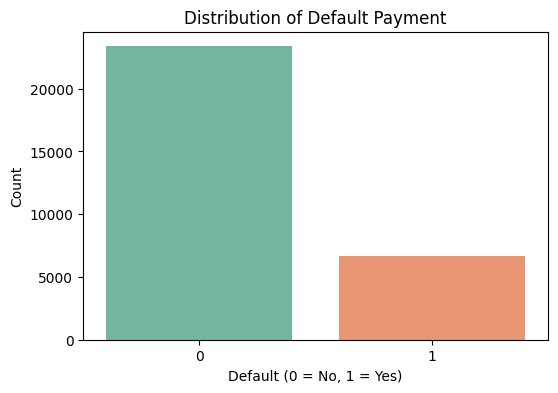

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Bar plot
plt.figure(figsize=(6,4))
sns.countplot(x='default', data=df, palette='Set2')
plt.title('Distribution of Default Payment')
plt.xlabel('Default (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()


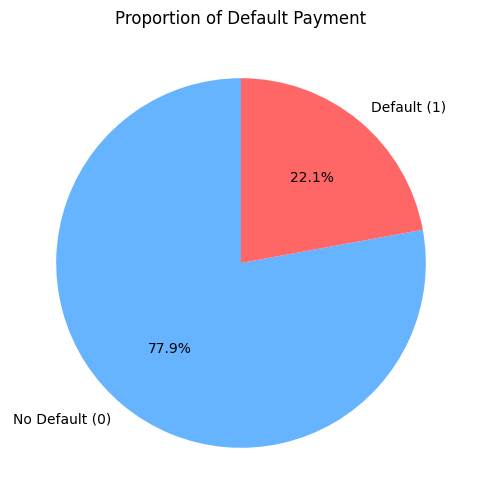

In [16]:
# Pie chart
counts = df['default'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(counts, labels=['No Default (0)', 'Default (1)'], autopct='%1.1f%%', colors=['#66b3ff','#ff6666'], startangle=90)
plt.title('Proportion of Default Payment')
plt.show()


**Observations for report**
- The dataset is imbalanced:
  - Non-default (0)  - 78%
  - Default (1) - 22%
- This is typical for credit card datasets — most clients do not default.
- When training the model, We might consider:
  - Using class weights
  - Using oversampling/undersampling techniques (SMOTE, etc.)

In [17]:
df['EDUCATION'].value_counts().sort_index()


,count
EDUCATION,
0,14
1,10585
2,14030
3,4917
4,123
5,280
6,51


## **Combine EDUCATION = 0, 5, 6 into one category**


In [18]:
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})


In [19]:
import pandas as pd

# Create an empty summary table
cat_summary = pd.DataFrame(columns=['Column', 'Category', 'Count', 'Explanation'])

# Define explanations including unknown categories
explanations = {
    'SEX': {1: 'Male', 2: 'Female'},
    'EDUCATION': {
        1:'Graduate School',
        2:'University',
        3:'High School',
        4:'Others'
    },
    'MARRIAGE': {1:'Married', 2:'Single', 3:'Others'}
}

# Fill the summary table
for col in explanations:
    for cat, desc in explanations[col].items():
        count = df[col].value_counts().get(cat, 0)
        cat_summary = pd.concat([
            cat_summary,
            pd.DataFrame({
                'Column':[col],
                'Category':[cat],
                'Count':[count],
                'Explanation':[desc]
            })
        ], ignore_index=True)

# Reset index
cat_summary.reset_index(drop=True, inplace=True)

# Display
cat_summary


,Column,Category,Count,Explanation
0,SEX,1,11888,Male
1,SEX,2,18112,Female
2,EDUCATION,1,10585,Graduate School
3,EDUCATION,2,14030,University
4,EDUCATION,3,4917,High School
5,EDUCATION,4,468,Others
6,MARRIAGE,1,13659,Married
7,MARRIAGE,2,15964,Single
8,MARRIAGE,3,323,Others


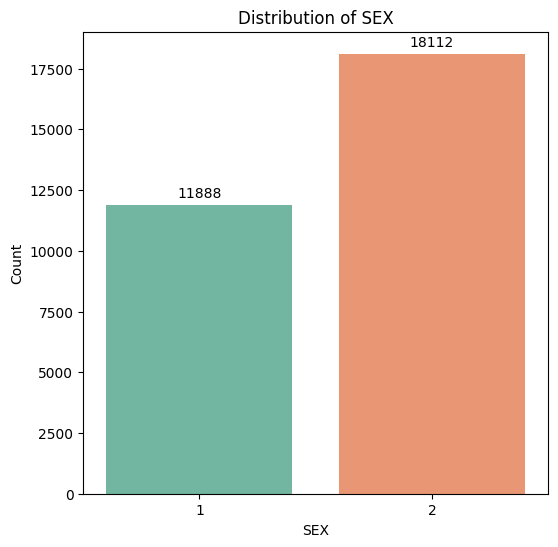

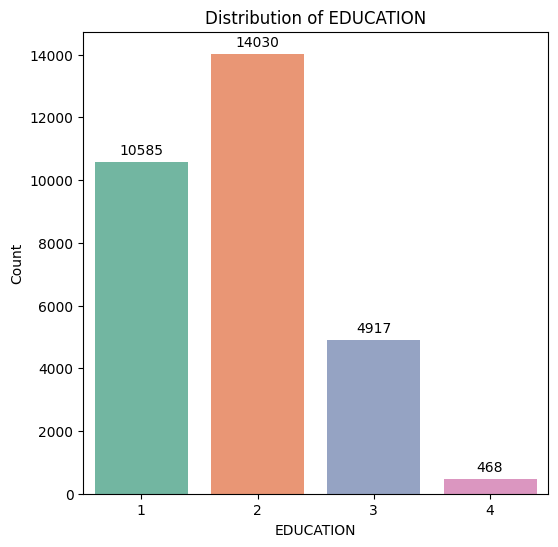

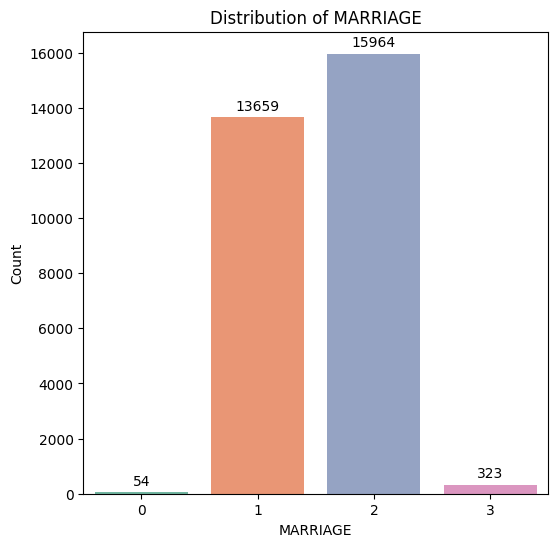

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = ['SEX', 'EDUCATION', 'MARRIAGE']

for col in categorical_cols:
    plt.figure(figsize=(6,6))
    ax = sns.countplot(x=col, data=df, palette='Set2')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

    # Add counts on top of bars
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=10,
                    color='black',
                    xytext=(0,3), textcoords='offset points')

    plt.show()


**Observations: Categorical Variables**

**SEX**
- There are 11,888 male and 18,112 female clients in the dataset.
- Females make up the majority (~60%) of the dataset.

**EDUCATION**
- Most clients have University education (14,030), followed by Graduate School (10,585) and High School (4,917).
- A small number of clients fall into Others (123) or Unknown/Miscellaneous (345 combined for 0, 5, 6).
- This indicates that education is mostly concentrated in higher education levels.

**MARRIAGE**
- Majority of clients are Single (15,964), followed by Married (13,659).
- Very few fall into Others (323).

In [21]:
# Group by SEX and count defaults
group_sex = df.groupby('SEX')['default'].value_counts().unstack(fill_value=0)
group_sex


default,0,1
SEX,,
1,9015,2873
2,14349,3763


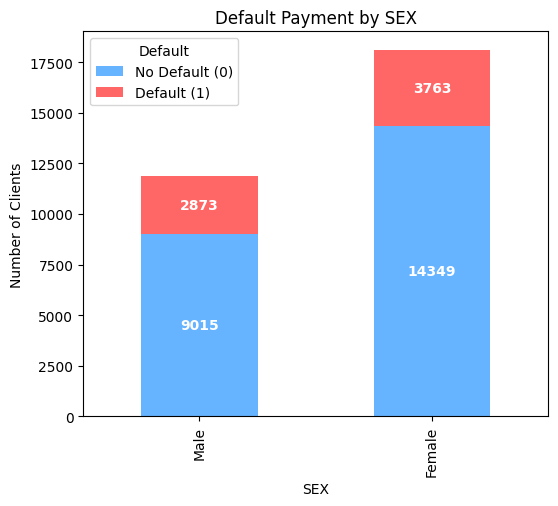

In [22]:
import matplotlib.pyplot as plt

# Group by SEX
group_sex = df.groupby('SEX')['default'].value_counts().unstack(fill_value=0)

# Map SEX codes to names
group_sex.index = ['Male', 'Female']

# Plot stacked bar chart
ax = group_sex.plot(kind='bar', stacked=True, figsize=(6,5), color=['#66b3ff','#ff6666'])
plt.title('Default Payment by SEX')
plt.xlabel('SEX')
plt.ylabel('Number of Clients')

# Add counts on top of each stack
for i, idx in enumerate(group_sex.index):
    bottom = 0
    for j, val in enumerate(group_sex.loc[idx]):
        ax.text(i, bottom + val/2, str(val), ha='center', va='center', color='white', fontweight='bold')
        bottom += val

# Add legend
plt.legend(title='Default', labels=['No Default (0)', 'Default (1)'])
plt.show()


**Observation**
- When we look at our clients by gender, we see that out of 11,888 male clients, 2,873 defaulted, giving a default rate of about 24%. For female clients, 3,763 out of 18,112 defaulted, which is roughly 21%.
- This tells us that while there are more female clients overall, a slightly higher proportion of male clients tend to default. Understanding this difference can help us tailor our risk management strategies more effectively.

In [23]:
# Group by EDUCATION and MARRIAGE and count defaults
group_edu_marriage = df.groupby(['EDUCATION', 'MARRIAGE'])['default'].value_counts().unstack(fill_value=0)
group_edu_marriage


default                0     1
EDUCATION MARRIAGE            
1         0            4     0
          1         2953   769
          2         5555  1254
          3           37    13
2         0            5     1
          1         5176  1666
          2         5401  1619
          3          118    44
3         0           40     4
          1         2107   754
          2         1457   452
          3           76    27
4         1          217    17
          2          210    16
          3            8     0

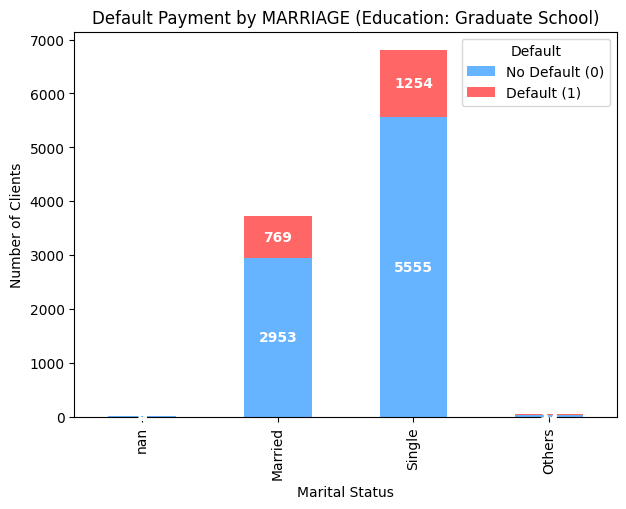

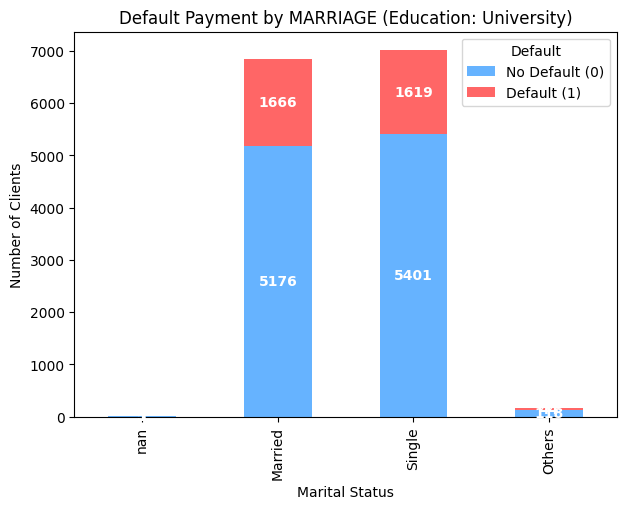

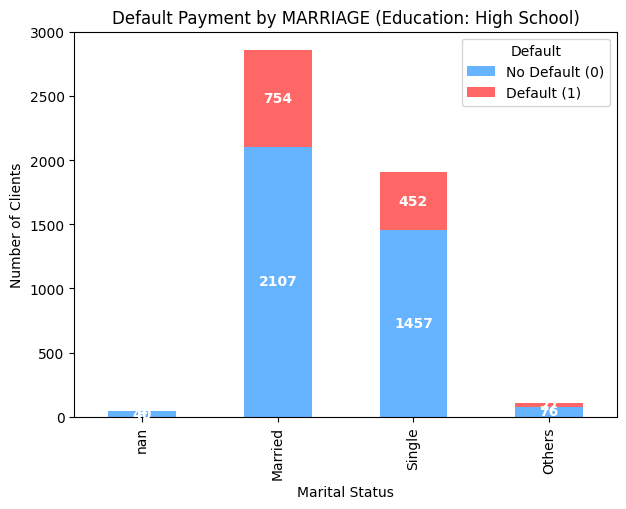

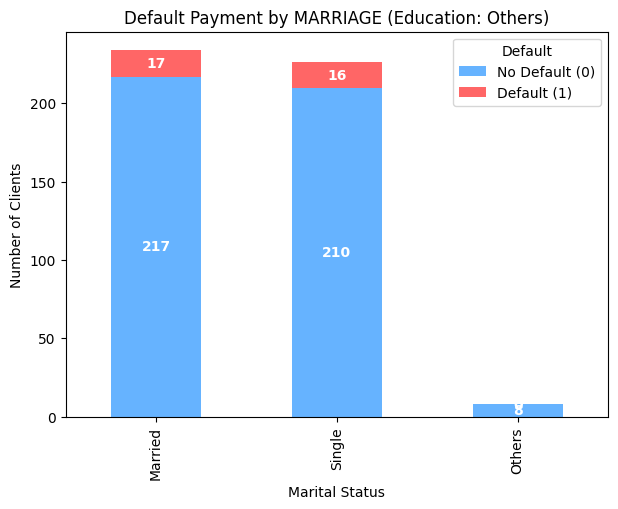

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

# Group by EDUCATION and MARRIAGE
group_edu_marriage = df.groupby(['EDUCATION', 'MARRIAGE'])['default'].value_counts().unstack(fill_value=0)

# Map codes to names for readability
education_map = {1:'Graduate School', 2:'University', 3:'High School', 4:'Others'}
marriage_map = {1:'Married', 2:'Single', 3:'Others'}

# Reset index to plot easily
plot_df = group_edu_marriage.reset_index()
plot_df['EDUCATION'] = plot_df['EDUCATION'].map(education_map)
plot_df['MARRIAGE'] = plot_df['MARRIAGE'].map(marriage_map)

# Create a stacked bar plot for each EDUCATION, separated by MARRIAGE
for edu in plot_df['EDUCATION'].unique():
    subset = plot_df[plot_df['EDUCATION'] == edu]
    ax = subset.set_index('MARRIAGE')[[0, 1]].plot(kind='bar', stacked=True, figsize=(7,5), color=['#66b3ff','#ff6666'])
    plt.title(f'Default Payment by MARRIAGE (Education: {edu})')
    plt.xlabel('Marital Status')
    plt.ylabel('Number of Clients')

    # Add counts on top of each stack
    for i, idx in enumerate(subset['MARRIAGE']):
        bottom = 0
        for j, val in enumerate([subset.iloc[i][0], subset.iloc[i][1]]):
            ax.text(i, bottom + val/2, str(val), ha='center', va='center', color='white', fontweight='bold')
            bottom += val

    plt.legend(title='Default', labels=['No Default (0)', 'Default (1)'])
    plt.show()


- For Graduate School educated clients (EDUCATION = 1), single clients default less compared to married clients, showing a lower risk of default.
- For University educated clients (EDUCATION = 2), the number of defaults is higher for both married and single clients, indicating a moderate default risk.
- Clients with High School education (EDUCATION = 3) show a relatively higher tendency to default, especially among married clients.
- The Others / Unknown education category (EDUCATION = 4) has very few observations, so its default behavior should be interpreted with caution.
- Overall, married clients tend to default more than single clients across most education levels.

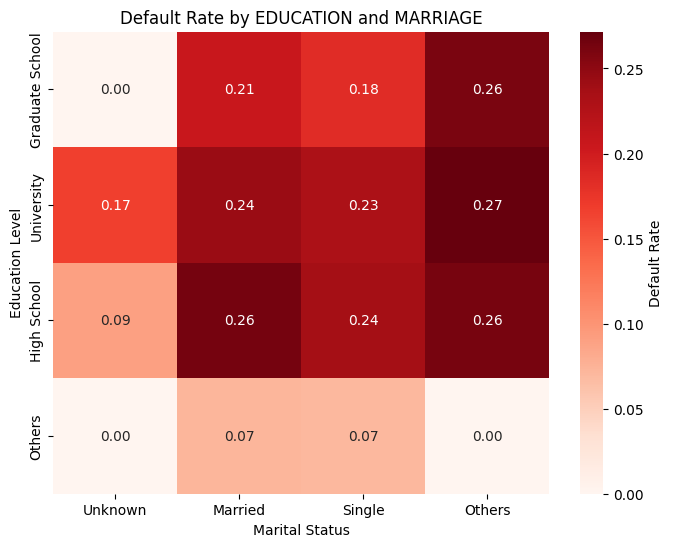

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Group by EDUCATION and MARRIAGE and calculate default rates
group = df.groupby(['EDUCATION', 'MARRIAGE'])['default'].mean().unstack(fill_value=0)

# Map EDUCATION and MARRIAGE codes to readable names, using get() to avoid KeyError
education_map = {1:'Graduate School', 2:'University', 3:'High School', 4:'Others'}
marriage_map = {1:'Married', 2:'Single', 3:'Others'}

group.index = [education_map.get(i, 'Unknown') for i in group.index]
group.columns = [marriage_map.get(i, 'Unknown') for i in group.columns]

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(group, annot=True, fmt=".2f", cmap="Reds", cbar_kws={'label': 'Default Rate'})
plt.title('Default Rate by EDUCATION and MARRIAGE')
plt.xlabel('Marital Status')
plt.ylabel('Education Level')
plt.show()


**Observation**
- **Graduate School clients** have the lowest default rates, especially singles (18%) and married (21%).
- **University clients** show moderate risk, with married (24%) and others (27%) defaulting more.
- **High School clients** have the highest default rates, particularly married or 'others' (around 26%).
- **Married clients** generally default more than singles across all education levels.
- The 'Others' education group shows low defaults, but the sample is very small, so interpret with caution.
- **Key insight:** Education and marital status together influence default behavior—lower education and married status increase risk, while higher education and being single reduce it.”

## **Numerical Features**

In [26]:
df[['LIMIT_BAL', 'AGE']].describe()


,LIMIT_BAL,AGE
count,30000.000000,30000.000000
mean,167484.322667,35.485500
std,129747.661567,9.217904
min,10000.000000,21.000000
25%,50000.000000,28.000000
50%,140000.000000,34.000000
75%,240000.000000,41.000000
max,1000000.000000,79.000000


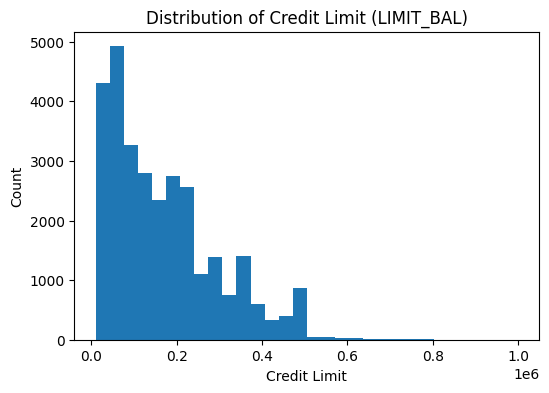

In [27]:
plt.figure(figsize=(6,4))
plt.hist(df['LIMIT_BAL'], bins=30)
plt.title('Distribution of Credit Limit (LIMIT_BAL)')
plt.xlabel('Credit Limit')
plt.ylabel('Count')
plt.show()


**Observation - Credit Limit (LIMIT_BAL)**

- The distribution of LIMIT_BAL is right-skewed, meaning most clients have lower credit limits, while only a few clients have very high limits.
- The average credit limit is around 167,000 NT dollars, while the median is 140,000, showing the effect of high-value outliers.
- About 75% of clients have a credit limit below 240,000, indicating that high credit limits are less common.
- The presence of very large values (up to 1,000,000) suggests outliers, which may need scaling before modeling.

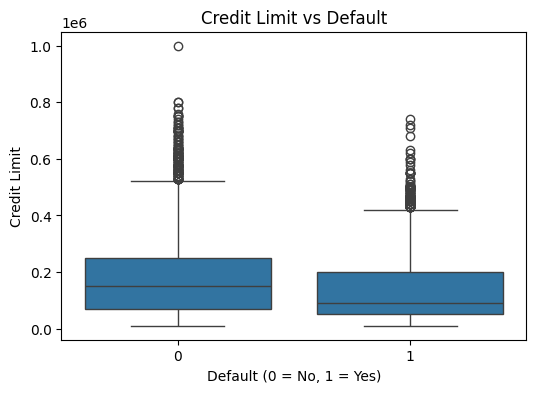

In [28]:
plt.figure(figsize=(6,4))
sns.boxplot(x='default', y='LIMIT_BAL', data=df)
plt.title('Credit Limit vs Default')
plt.xlabel('Default (0 = No, 1 = Yes)')
plt.ylabel('Credit Limit')
plt.show()

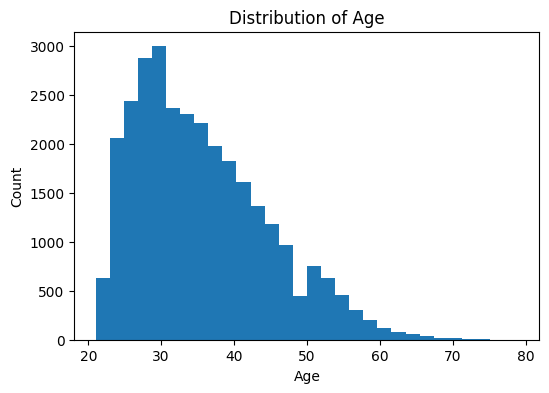

In [29]:
plt.figure(figsize=(6,4))
plt.hist(df['AGE'], bins=30)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


- The age distribution is approximately right-skewed with most clients between 25 and 45 years old.
- The average age is around 35 years, and the median age is 34, showing a fairly balanced distribution.
- Very few clients are older than 60 years, and the maximum age observed is 79.
- Compared to LIMIT_BAL, AGE shows less extreme variation.

## **Analysis of PAY Variables**

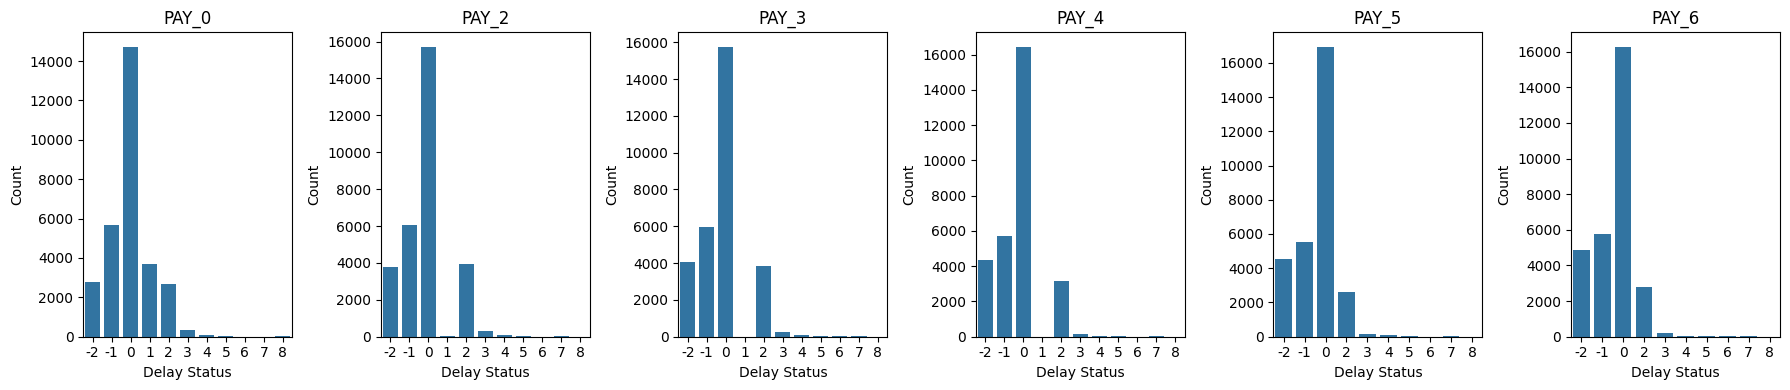

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

pay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']

plt.figure(figsize=(18,4))

for i, col in enumerate(pay_cols):
    plt.subplot(1, 6, i+1)
    sns.countplot(x=col, data=df)
    plt.title(col)
    plt.xlabel('Delay Status')
    plt.ylabel('Count')

plt.tight_layout()
plt.show()



### **PAY Variables vs Default**

In [31]:
df.groupby('default')[['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']].mean()


,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
default,,,,,,
0,-0.211222,-0.301917,-0.316256,-0.355633,-0.389488,-0.405624
1,0.668174,0.458258,0.362116,0.254521,0.167872,0.112116


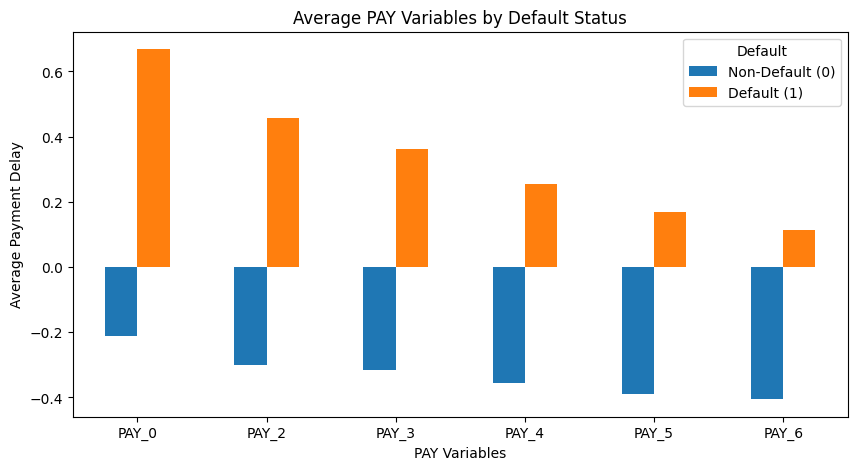

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Create dataframe from your values
pay_mean = pd.DataFrame({
    'PAY_0': [-0.211222, 0.668174],
    'PAY_2': [-0.301917, 0.458258],
    'PAY_3': [-0.316256, 0.362116],
    'PAY_4': [-0.355633, 0.254521],
    'PAY_5': [-0.389488, 0.167872],
    'PAY_6': [-0.405624, 0.112116]
}, index=['Non-Default (0)', 'Default (1)'])

# Plot
pay_mean.T.plot(kind='bar', figsize=(10,5))
plt.title('Average PAY Variables by Default Status')
plt.xlabel('PAY Variables')
plt.ylabel('Average Payment Delay')
plt.xticks(rotation=0)
plt.legend(title='Default')
plt.show()


- Clients who did not default (default = 0) have negative average PAY values, which indicates on-time payments or no payment delay.
- Clients who defaulted (default = 1) have positive average PAY values, showing consistent payment delays.
- The highest difference between defaulters and non-defaulters is seen in PAY_0, meaning the most recent repayment status is the strongest indicator of default.
- As we move from PAY_0 to PAY_6, the average PAY values for defaulters gradually decrease, showing that recent payment behavior is more influential than older history.

**Conclusion**
- Past payment behavior has a strong impact on default prediction.
- Clients with recent payment delays are much more likely to default, making PAY variables critical features for the deep learning model.

## **Calculate Correlation Matrix**
Calculate the Pearson correlation matrix for all numerical features in the DataFrame, including the target variable ('default').


In [33]:
correlation_matrix = df.corr(method='pearson')
print("Correlation Matrix calculated successfully.")

Correlation Matrix calculated successfully.


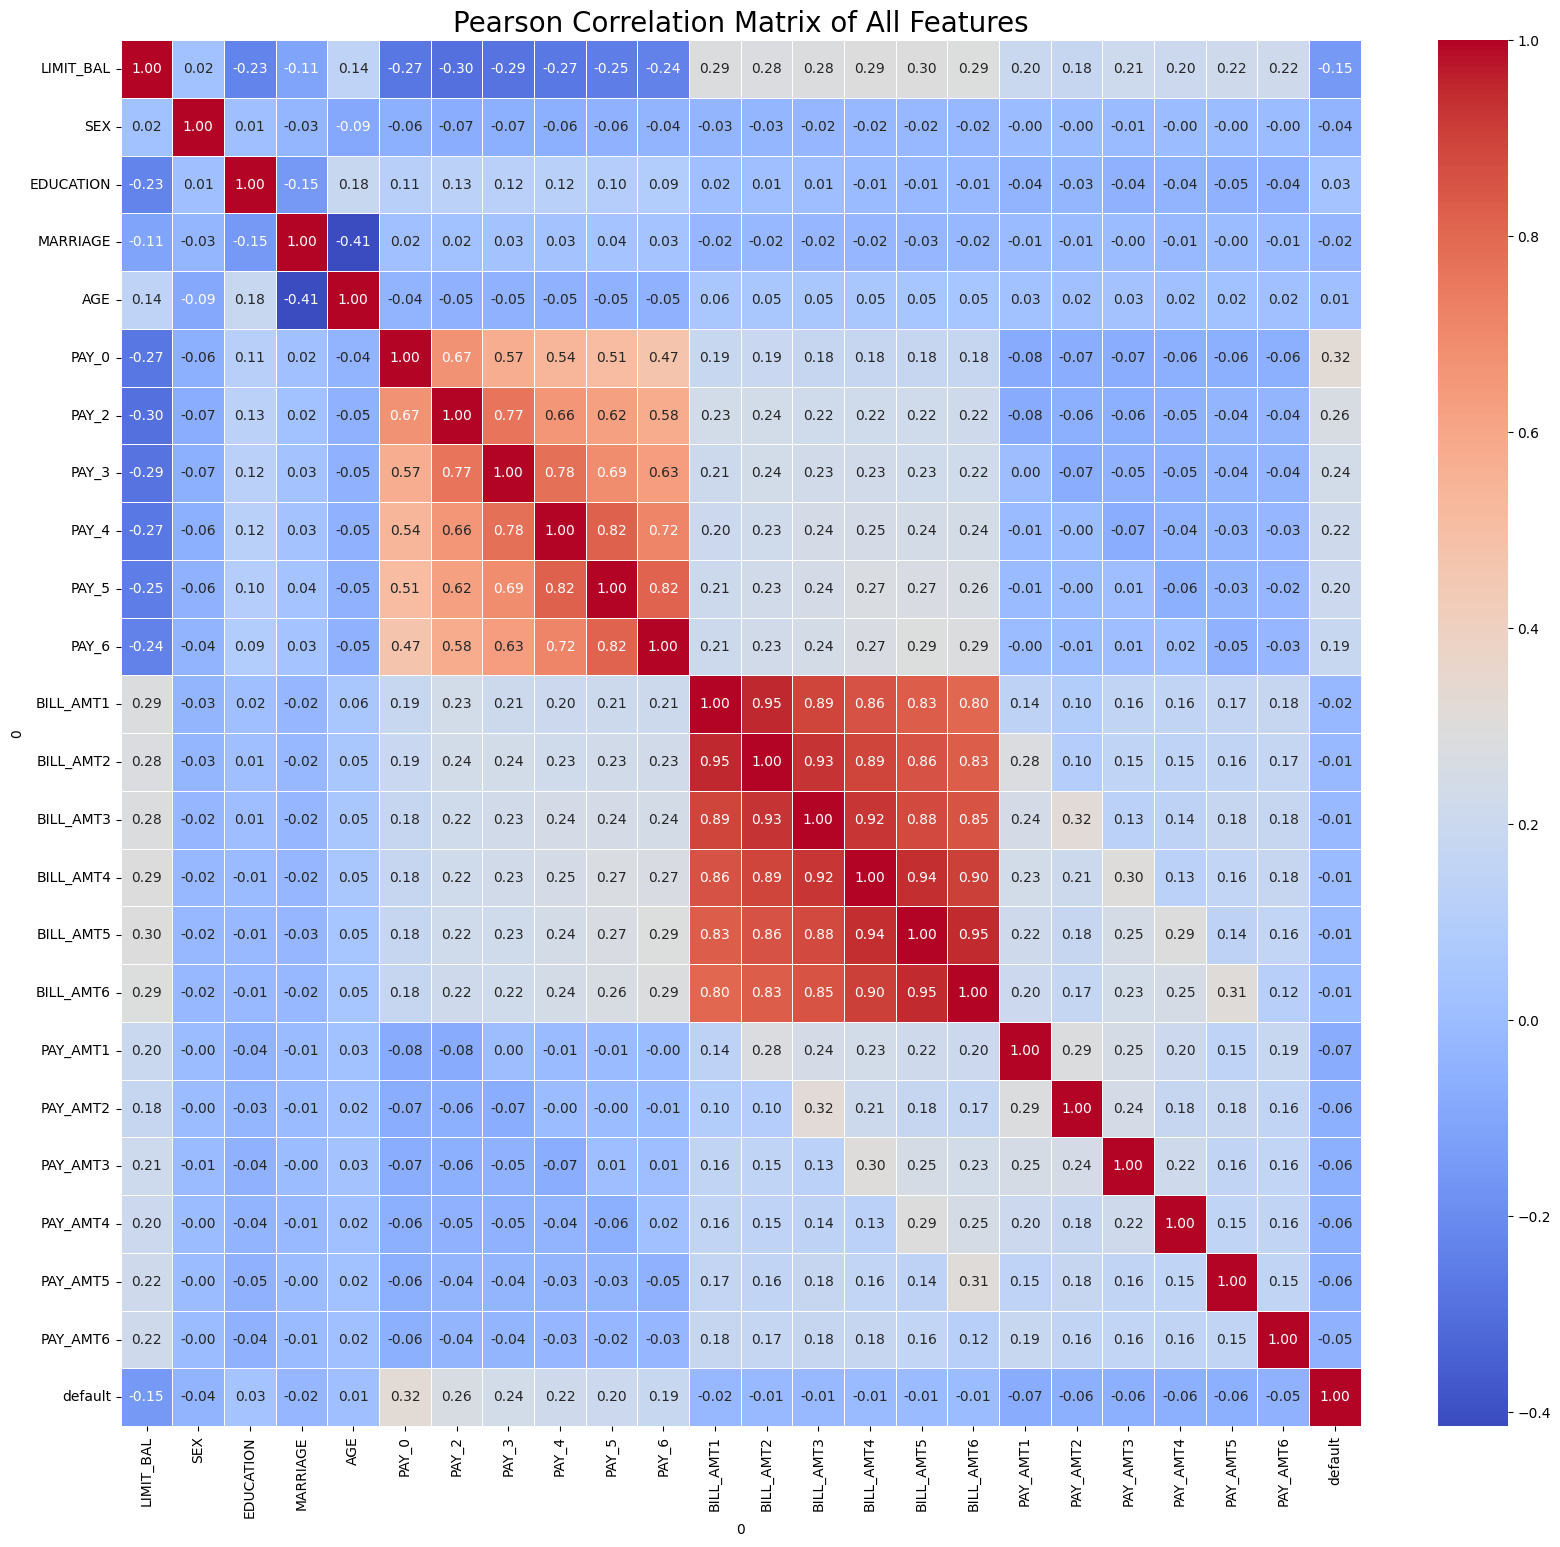

In [34]:
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Pearson Correlation Matrix of All Features', fontsize=20)
plt.show()

- The PAY_ variables show the strongest positive correlation with the default variable, indicating that payment delays are the most important predictors of credit card default.
- PAY_0 (most recent repayment status) has the highest correlation with default, showing that recent payment behavior is more influential than older payment history.
- LIMIT_BAL is negatively correlated with default, meaning customers with higher credit limits are less likely to default.
- EDUCATION also shows a negative correlation with default, suggesting higher education levels are associated with lower default risk.
- AGE has a very weak negative correlation, indicating that older customers are slightly less likely to default.
- SEX and MARRIAGE show very weak correlations with default, suggesting limited predictive power on their own.
- BILL_AMT and PAY_AMT variables have weak or negligible direct correlations with default, but may still be useful when analyzed over time.

# **Engineered Features for Credit Risk Modeling**

1. **pay_trend**
   - Measures whether a customer's overall repayment behavior is improving or worsening over time.
   - Helps identify clients whose payment patterns are gradually deteriorating.

2. **recent_vs_past_pay**
   - Captures sudden recent delays compared to past behavior.
   - Useful for detecting early warning signs of potential defaults.

3. **payment_variability**
   - Measures unstable or inconsistent payment behavior month-to-month.
   - Highlights customers with irregular repayment patterns that may indicate risk.

4. **delay_acceleration**
   - Quantifies the speed at which repayment delays are worsening.
   - Helps distinguish slow deterioration from rapid financial stress.

5. **worsening_months**
   - Counts the number of months a customer has shown worsening repayment.
   - Reflects the persistence of deteriorating behavior over time.

6. **avg_pay_status**
   - Average repayment status across months PAY_0–PAY_6.
   - Provides a summary of overall repayment performance over time.

7. **BILL_UTIL1-6 (Monthly credit utilization ratios)**
   - Ratio of each month’s bill to credit limit.
   - Indicates how much of available credit a customer is using, month by month.

8. **avg_bill_util & max_bill_util (Aggregate utilization measures)**
   - Average and maximum utilization across six months.
   - Captures sustained and peak borrowing intensity, which can signal financial stress.

9. **BILL_AMT_DIFF1-5 (Month-to-month bill changes)**
   - Difference between consecutive monthly bill amounts.
   - Tracks spending trends and changes in financial behavior.

10. **longest_pay_delay_streak**
   - Maximum number of consecutive months with delayed payment.
   - Highlights persistent delinquency, which is a strong predictor of default.

**Insight:** These engineered features transform raw credit data into meaningful behavioral signals, allowing the model to better capture repayment trends, sudden changes, and risk patterns.

In [35]:
# Average repayment status
pay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
df['avg_pay_status'] = df[pay_cols].mean(axis=1)

# Credit utilization
bill_amt_cols = ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']
bill_util_cols = []

df['LIMIT_BAL_SAFE'] = df['LIMIT_BAL'].replace(0, pd.NA)

for i, col in enumerate(bill_amt_cols):
    util_col = f'BILL_UTIL{i+1}'
    df[util_col] = df[col] / df['LIMIT_BAL_SAFE']
    bill_util_cols.append(util_col) # <--- Added this line to populate the list

# Aggregate utilization features
df['avg_bill_util'] = df[bill_util_cols].mean(axis=1)
df['max_bill_util'] = df[bill_util_cols].max(axis=1)

In [36]:
for i in range(1, 6):
    df[f'BILL_AMT_DIFF{i}'] = df[f'BILL_AMT{i}'] - df[f'BILL_AMT{i+1}']

print("Month-to-month BILL_AMT differences calculated.")

Month-to-month BILL_AMT differences calculated.


In [37]:
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

def calculate_longest_delay_streak(row):
    current_streak = 0
    max_streak = 0
    for col in pay_cols:
        # A payment delay is indicated by PAY_N > 0
        if row[col] > 0:
            current_streak += 1
        else:
            max_streak = max(max_streak, current_streak)
            current_streak = 0
    max_streak = max(max_streak, current_streak) # Check for streak ending at the last month
    return max_streak

df['longest_pay_delay_streak'] = df.apply(calculate_longest_delay_streak, axis=1)

print("Longest consecutive payment delay streak calculated successfully.")

Longest consecutive payment delay streak calculated successfully.


In [38]:
# Temporal Feature Engineering

import numpy as np

# Repayment history columns (ordered from oldest → most recent)
pay_cols = ['PAY_6', 'PAY_5', 'PAY_4', 'PAY_3', 'PAY_2', 'PAY_0']

# Repayment Trend (overall worsening or improving)
def repayment_trend(row):
    y = row.values
    x = np.arange(len(y))
    slope = np.polyfit(x, y, 1)[0]
    return slope

df['pay_trend'] = df[pay_cols].apply(repayment_trend, axis=1)

# Recent vs Past Repayment (sudden deterioration)
df['recent_vs_past_pay'] = df['PAY_0'] - df[['PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']].mean(axis=1)

# Repayment Volatility (instability over months)
df['payment_variability'] = df[pay_cols].std(axis=1)

# Delay Acceleration (recent worsening speed)
df['delay_acceleration'] = df['PAY_0'] - df['PAY_2']

# Worsening Months Count (consecutive deterioration)
def worsening_months(row):
    vals = row.values
    count = 0
    for i in range(1, len(vals)):
        if vals[i] > vals[i-1]:
            count += 1
    return count

df['worsening_months'] = df[pay_cols].apply(worsening_months, axis=1)

print("Temporal repayment features created successfully.")


Temporal repayment features created successfully.


In [39]:
engineered_features = [
    'avg_pay_status', 'avg_bill_util', 'max_bill_util', 'longest_pay_delay_streak','pay_trend','recent_vs_past_pay',
    'payment_variability','delay_acceleration', 'worsening_months']

# Check if all features exist in the dataframe
missing_features = [f for f in engineered_features if f not in df.columns]
if missing_features:
    print("Missing features:", missing_features)
else:
    print("All features exist in the dataset.\n")

# Quick look at the first few rows
print("First 5 rows of engineered features:")
print(df[engineered_features].head(), "\n")

# Summary statistics
print("Summary statistics:")
print(df[engineered_features].describe(), "\n")

# Check for null values
print("Null values per feature:")
print(df[engineered_features].isnull().sum())



All features exist in the dataset.

First 5 rows of engineered features:
0  avg_pay_status  avg_bill_util  max_bill_util  longest_pay_delay_streak  \
0       -0.333333       0.064200       0.195650                         2   
1        0.500000       0.023718       0.028792                         1   
2        0.000000       0.188246       0.324878                         0   
3        0.000000       0.771113       0.985820                         0   
4       -0.333333       0.364463       0.716700                         0   

0  pay_trend  recent_vs_past_pay  payment_variability  delay_acceleration  \
0   0.914286                 2.8             1.861899                   0   
1  -0.257143                -1.8             1.224745                  -3   
2   0.000000                 0.0             0.000000                   0   
3   0.000000                 0.0             0.000000                   0   
4  -0.171429                -0.8             0.516398                  -1   

0

In [40]:
df.drop(columns=bill_util_cols, inplace=True)

In [41]:
correlation_matrix_new = df.corr(method='pearson')
print("New Correlation Matrix calculated successfully.")

New Correlation Matrix calculated successfully.


## **Correlation heatmap for engineered features with 'default'**

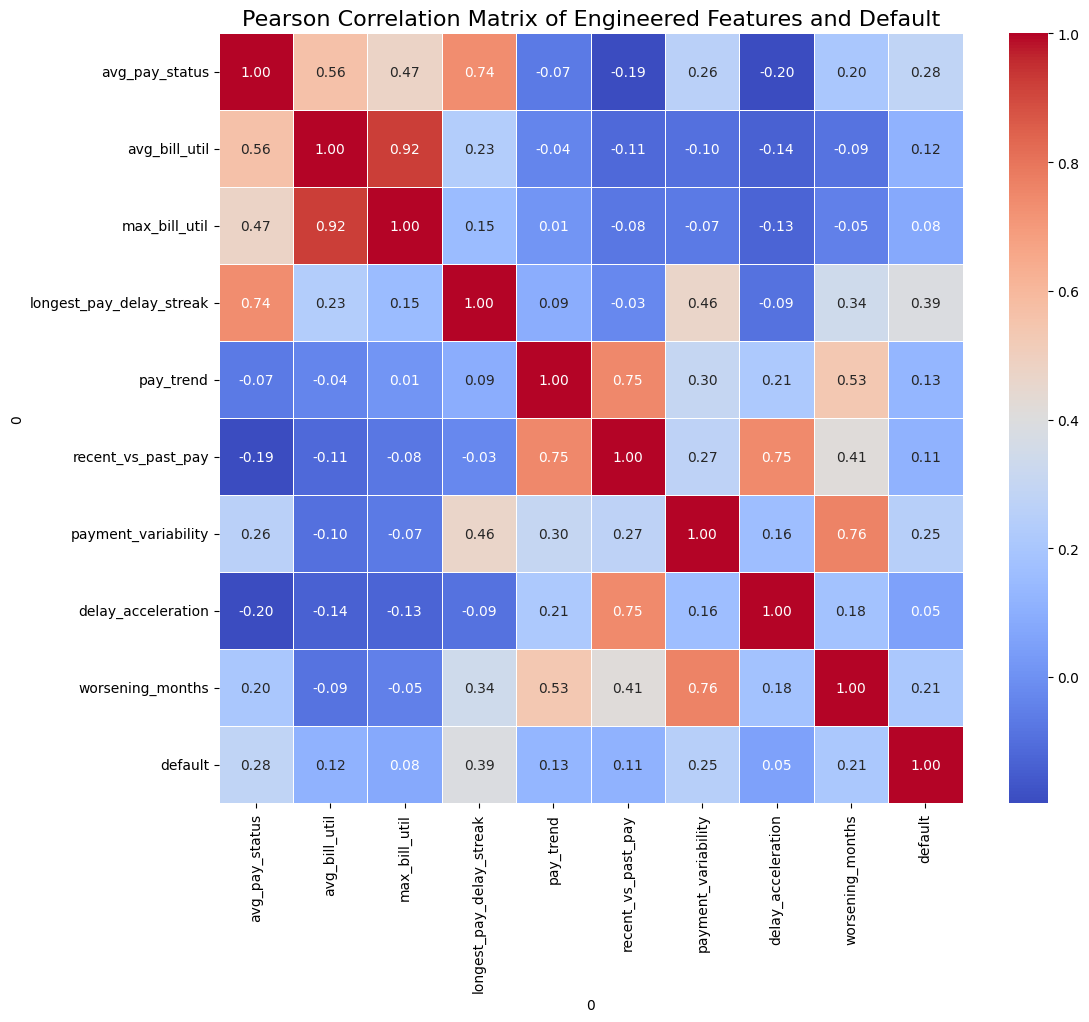

Correlation heatmap for engineered features with 'default' displayed successfully.


In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the list of engineered features and add the 'default' target variable
engineered_features_with_target = engineered_features + ['default']

# Create a subset of the DataFrame with only these columns
df_subset = df[engineered_features_with_target]

# Calculate the correlation matrix for this subset
correlation_matrix_engineered = df_subset.corr(method='pearson')

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_engineered, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Pearson Correlation Matrix of Engineered Features and Default', fontsize=16)
plt.show()

print("Correlation heatmap for engineered features with 'default' displayed successfully.")

In [43]:
engineered_features = ['avg_pay_status', 'avg_bill_util', 'max_bill_util', 'longest_pay_delay_streak','pay_trend','recent_vs_past_pay',
                       'payment_variability','delay_acceleration', 'worsening_months' ]
correlations_with_default = correlation_matrix_new.loc[engineered_features, 'default']
print("Correlations of engineered features with 'default':")
display(correlations_with_default)

Correlations of engineered features with 'default':


,default
0,
avg_pay_status,0.281955
avg_bill_util,0.115483
max_bill_util,0.081577
longest_pay_delay_streak,0.388552
pay_trend,0.129735
recent_vs_past_pay,0.114562
payment_variability,0.248922
delay_acceleration,0.052526
worsening_months,0.206373


**Observation: Correlation of Engineered Features with Default**
- **longest_pay_delay_streak (0.39)** shows the strongest positive correlation with default, indicating that customers with long continuous payment delays are highly likely to default.
- **avg_pay_status (0.28) and payment_variability (0.25)** also have strong correlations, meaning consistently late and unstable payment behavior increases default risk.
- **worsening_months (0.21)** suggests that repeated deterioration in repayment over time is linked to higher default probability.
- **pay_trend (0.13) and recent_vs_past_pay (0.11)** confirm that worsening or recently declined payment patterns contribute to default.
- Credit utilization features **avg_bill_util (0.12) and max_bill_util** (0.08) show moderate relationships, indicating that higher credit usage slightly raises default risk.
- **delay_acceleration (0.05)** has the weakest correlation but still reflects that faster increases in delay are associated with default.
- Overall: Features capturing persistent and worsening repayment delays are the most influential indicators of credit default.

## **Correlation heatmap for all features (original and engineered)**

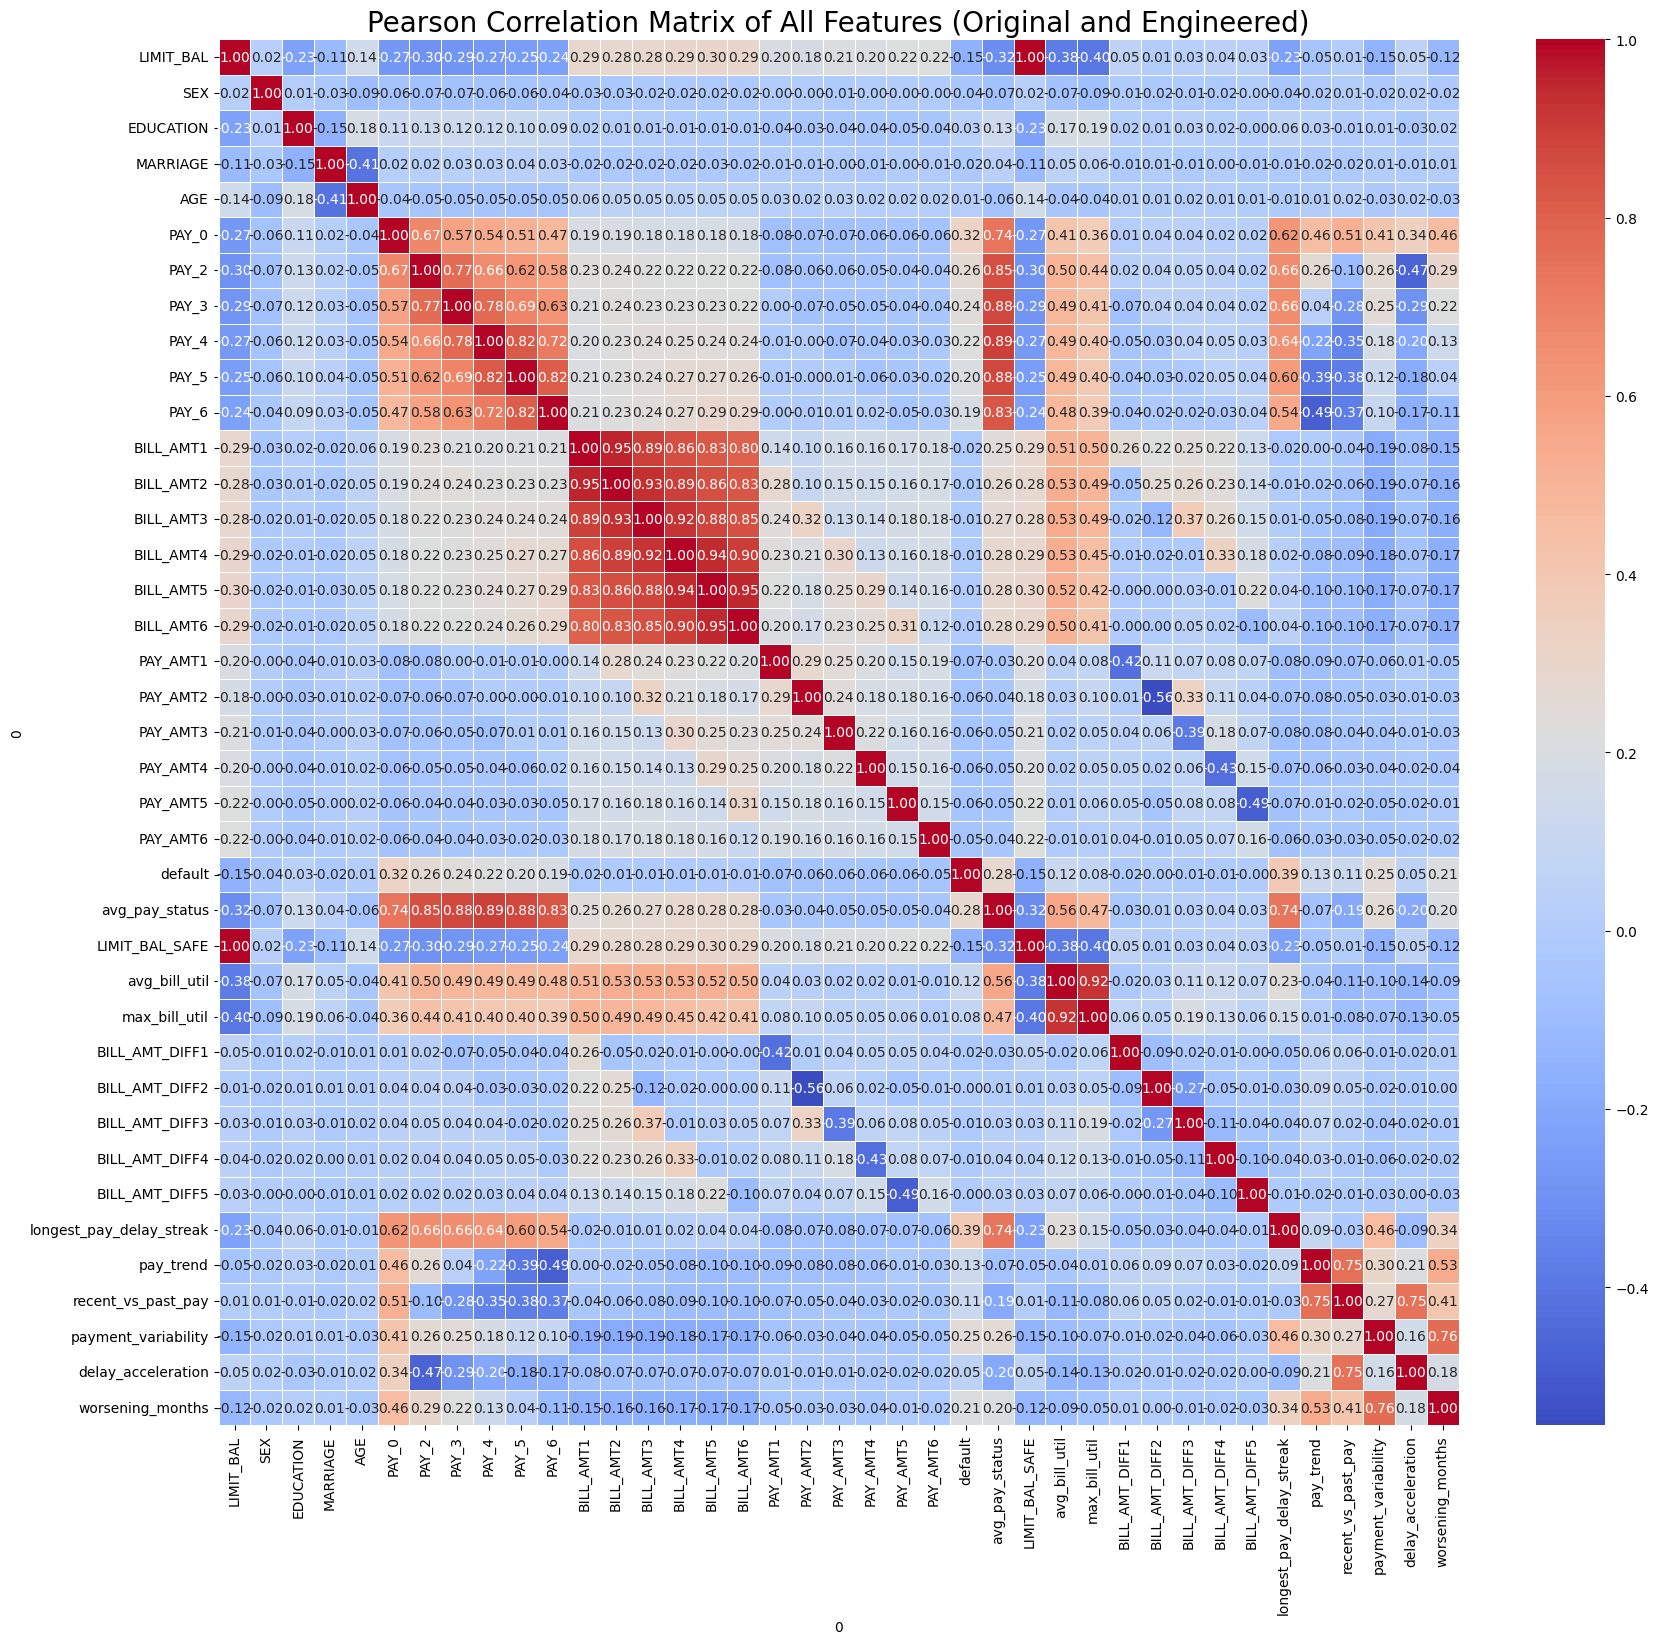

Correlation heatmap for all features (original and engineered) displayed successfully.


In [44]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix_new, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Pearson Correlation Matrix of All Features (Original and Engineered)', fontsize=20)
plt.show()

print("Correlation heatmap for all features (original and engineered) displayed successfully.")

**Correlation with Target Variable (Default)**
- Past repayment behavior features (PAY_0, PAY_2) and engineered repayment features (avg_pay_status, longest_pay_delay_streak, payment_variability, worsening_months, pay_trend, recent_vs_past_pay) show the strongest positive correlations with default.
- This confirms that recent, persistent, and unstable payment delays are the most critical indicators of credit default.
- LIMIT_BAL shows the strongest negative correlation ( −0.15), indicating that customers with higher credit limits are less likely to default.
- Credit utilization features (avg_bill_util, max_bill_util) have moderate positive correlations, suggesting that higher credit usage relative to limit increases default risk.
- Demographic variables (SEX, EDUCATION, MARRIAGE, AGE) show weak correlations, indicating limited direct predictive power compared to repayment behavior.

## **Data Preprocessing and Preparation for Modeling**

#### **Separate Features and Target**

In [45]:
y = df['default']
X = df.drop('default', axis=1)

This step separates the target variable (default) from the input features.
Keeping X and y separate is essential for supervised learning and prevents the model from accidentally learning the target as an input feature.

#### **Split Data into Train, Validation, and Test Sets**

In [46]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(X_train.shape, X_val.shape, X_test.shape)


(21000, 38) (4500, 38) (4500, 38)


#### **Feature Processing (Encoding)**

In [47]:
categorical_features = ['SEX', 'EDUCATION', 'MARRIAGE']

numerical_features = [
    'LIMIT_BAL','AGE',
    'PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6',
    'BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6',
    'PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6',
    'avg_pay_status','avg_bill_util','max_bill_util',
    'BILL_AMT_DIFF1', 'BILL_AMT_DIFF2', 'BILL_AMT_DIFF3', 'BILL_AMT_DIFF4', 'BILL_AMT_DIFF5',
    'longest_pay_delay_streak','pay_trend','recent_vs_past_pay',
                       'payment_variability','delay_acceleration', 'worsening_months'
]

# One-hot encode
X_train_cat = pd.get_dummies(X_train[categorical_features], drop_first=True)
X_val_cat   = pd.get_dummies(X_val[categorical_features], drop_first=True)
X_test_cat  = pd.get_dummies(X_test[categorical_features], drop_first=True)

# Align columns
cols = X_train_cat.columns
X_val_cat = X_val_cat.reindex(columns=cols, fill_value=0)
X_test_cat = X_test_cat.reindex(columns=cols, fill_value=0)

# Combine
X_train_processed = pd.concat([X_train[numerical_features], X_train_cat], axis=1)
X_val_processed   = pd.concat([X_val[numerical_features], X_val_cat], axis=1)
X_test_processed  = pd.concat([X_test[numerical_features], X_test_cat], axis=1)

#### **Scaling**

In [48]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_processed)
X_val_scaled   = scaler.transform(X_val_processed)
X_test_scaled  = scaler.transform(X_test_processed)

**What the Model Is** A fully connected neural network (FCNN) is a deep learning model where every neuron in one layer connects to all neurons in the next layer.
- In this project, the model learns relationships between:
  - customer demographics
  - credit history
  - payment behaviour
  - billing information

### **Baseline Model with no Class weights**

In [49]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix


# Baseline Model Architecture
baseline_model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

baseline_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        Precision(name="precision"),
        Recall(name="recall")
    ]
)

baseline_model.summary()

# Training
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_baseline = baseline_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

# Evaluation
y_test_proba = baseline_model.predict(X_test_scaled)
y_pred = (y_test_proba > 0.50).astype(int)

cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Baseline Model Results (threshold=0.50)")
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", report)

tn, fp, fn, tp = cm.ravel()
print("\nValues:")
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,545 (17.75 KB)

 Trainable params: 4,545 (17.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8034 - loss: 0.4787 - precision: 0.5964 - recall: 0.2885 - val_accuracy: 0.8098 - val_loss: 0.4501 - val_precision: 0.6270 - val_recall: 0.2788
Epoch 2/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8195 - loss: 0.4332 - precision: 0.6667 - recall: 0.3518 - val_accuracy: 0.8093 - val_loss: 0.4497 - val_precision: 0.6208 - val_recall: 0.2850
Epoch 3/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8201 - loss: 0.4281 - precision: 0.6703 - recall: 0.3519 - val_accuracy: 0.8100 - val_loss: 0.4492 - val_precision: 0.6244 - val_recall: 0.2860
Epoch 4/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8219 - loss: 0.4246 - precision: 0.6762 - recall: 0.3588 - val_accuracy: 0.8102 - val_loss: 0.4495 - val_precision: 0.6270 - val_recall: 0.2839
Epoch 5/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8226 - loss: 0.4215 - precision: 0.6794 - recall: 0.3601 - val_accuracy: 0.8076 - val_loss: 0.

**Observations:**
- Overall Accuracy: 0.82 (misleading due to class imbalance).
- Class 0 (Non-Default): Precision 0.83, Recall 0.96, very good at identifying non-defaulters.
- Class 1 (Default): Precision 0.71, Recall 0.32, misses a large portion of defaulters (677 False Negatives).
- F1-score (Class 1): 0.44, poor balance between precision and recall.

**Conclusion:**
- Heavily biased toward the majority class.
- Effective for identifying safe customers, but fails at detecting defaulters, which is critical in credit risk.
- Not suitable for deployment.
- This confirms that training without imbalance handling leads to biased predictions toward the majority class.
- The results justify the need for imbalance-handling techniques such as:
  - class weighting
  - SMOTE oversampling
  - hyperparameter tuning
- These approaches aim to improve sensitivity to defaulters while maintaining overall model stability.

### **Model with Class Weights**

In [50]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
import joblib

# 1. Compute Class Weights
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced',
                               classes=classes,
                               y=y_train)

class_weights = {0: weights[0], 1: weights[1]}
print("Class Weights:", class_weights)

# 2. Build Model (same as baseline)
model_cw = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_cw.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 3. Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# 4. Train Model
history_cw = model_cw.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

# 5. Predictions (threshold=0.50)
y_prob = model_cw.predict(X_test_scaled)
y_pred = (y_prob >= 0.50).astype(int)

# 6. Evaluation
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

cm = confusion_matrix(y_test, y_pred)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("DL + Class Weights + Early Stopping")
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Save the scaler
joblib.dump(scaler, "scaler.pkl")
# Save the model
model_cw.save("credit_model.h5")

Class Weights: {0: np.float64(0.6432246998284734), 1: np.float64(2.245508982035928)}
Epoch 1/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6968 - loss: 0.6015 - val_accuracy: 0.7507 - val_loss: 0.5585
Epoch 2/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7636 - loss: 0.5631 - val_accuracy: 0.7500 - val_loss: 0.5534
Epoch 3/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7647 - loss: 0.5564 - val_accuracy: 0.7442 - val_loss: 0.5544
Epoch 4/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7639 - loss: 0.5520 - val_accuracy: 0.7416 - val_loss: 0.5527
Epoch 5/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7640 - loss: 0.5487 - val_accuracy: 0.7358 - val_loss: 0.5548
Epoch 6/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7652 - loss: 0.5459 - val_accuracy: 0.7351 - val_loss: 0.5526
Epoch 7/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7621 - loss: 0.5434 - val_accuracy: 0.7344 - val_loss: 0.5516
Epoch 8/50
657/657 

DL + Class Weights + Early Stopping
Precision: 0.46044776119402986
Recall: 0.6201005025125628
F1: 0.5284796573875803

Confusion Matrix:
 [[2782  723]
 [ 378  617]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.79      0.83      3505
           1       0.46      0.62      0.53       995

    accuracy                           0.76      4500
   macro avg       0.67      0.71      0.68      4500
weighted avg       0.79      0.76      0.77      4500



**Observations**
- Overall Accuracy: 0.76 (expected trade-off).
- Class 0: Recall decreased to 0.80, more False Positives (723).
- Class 1: Recall improved to 0.62 ,significantly fewer False Negatives (378).
- F1-score (Class 1): 0.54, better balance for the minority class.

**Conclusion:**
- Class weighting successfully shifted focus to detecting defaulters.
- Improves minority class detection at the cost of more false alarms for non-defaulters.
- A strong improvement over the baseline.

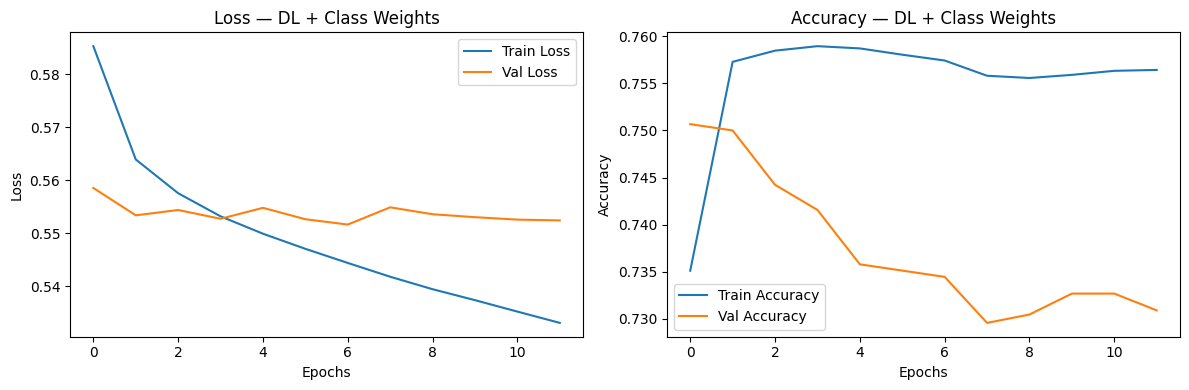

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

# Loss Plot
plt.subplot(1,2,1)
plt.plot(history_cw.history['loss'], label='Train Loss')
plt.plot(history_cw.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss — DL + Class Weights')
plt.legend()

# Accuracy Plot
plt.subplot(1,2,2)
plt.plot(history_cw.history['accuracy'], label='Train Accuracy')
plt.plot(history_cw.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy — DL + Class Weights')
plt.legend()

plt.tight_layout()
plt.show()


- Training loss decreases steadily across epochs.
- Validation loss decreases initially but then starts increasing after ~epoch 3–4 → early overfitting.
- Training accuracy improves slightly and stabilizes around 0.75.
- Validation accuracy gradually declines from 0.74 - 0.72.
- Clear gap between train and validation curves - model overfits quickly.
- Early stopping correctly stopped training around epoch 8 to prevent further overfitting.

### **Tuned Model with Class weights**

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 256)            │         9,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,481 (205.00 KB)

 Trainable params: 51,713 (202.00 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 12s 55ms/step - accuracy: 0.6504 - loss: 0.6918 - val_accuracy: 0.7431 - val_loss: 0.6080
Epoch 2/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6920 - loss: 0.6162 - val_accuracy: 0.7582 - val_loss: 0.5725
Epoch 3/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7058 - loss: 0.5988 - val_accuracy: 0.7342 - val_loss: 0.5832
Epoch 4/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7120 - loss: 0.5884 - val_accuracy: 0.7318 - val_loss: 0.5868
Epoch 5/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7135 - loss: 0.5803 - val_accuracy: 0.7402 - val_loss: 0.5752
Epoch 6/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7173 - loss: 0.5742 - val_accuracy: 0.7216 - val_loss: 0.5830
Epoch 7/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7235 - loss: 0.5727 - val_accuracy: 0.7229 - val_loss: 0.5829
Epoch 8/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7246 - loss: 0.5668 - val_accuracy: 0.7329

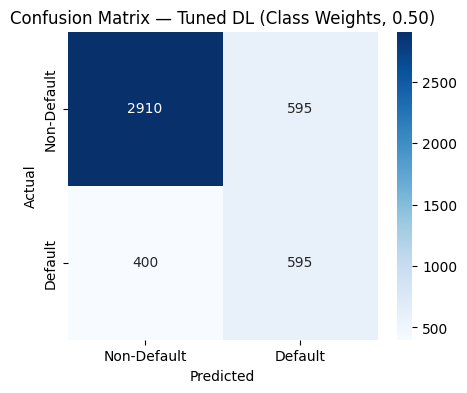

In [52]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Tuned Model Architecture
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# 3. Training with Class Weights
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=256,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

# 4. Evaluation (Threshold = 0.50)
y_test_proba = model.predict(X_test_scaled)
y_pred = (y_test_proba > 0.50).astype(int)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print("\nTuned DL (Class Weights, threshold=0.50)")
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 5. Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-Default","Default"],
            yticklabels=["Non-Default","Default"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Tuned DL (Class Weights, 0.50)")
plt.show()


**Tuned Deep Learning with Class Weights (Threshold 0.50)**

**Observations:**
- Overall Accuracy: 0.78, slight improvement.
- Class 0: Recall 0.83, False Positives = 595.
- Class 1: Recall = 0.60, Precision = 0.50, F1 = 0.55, best balance so far at threshold 0.50.

**Conclusion:**
- Architectural tuning (BatchNorm, Dropout) improves generalization.
- Slight improvement in F1 for minority class.
- More robust than simple class-weighted model.

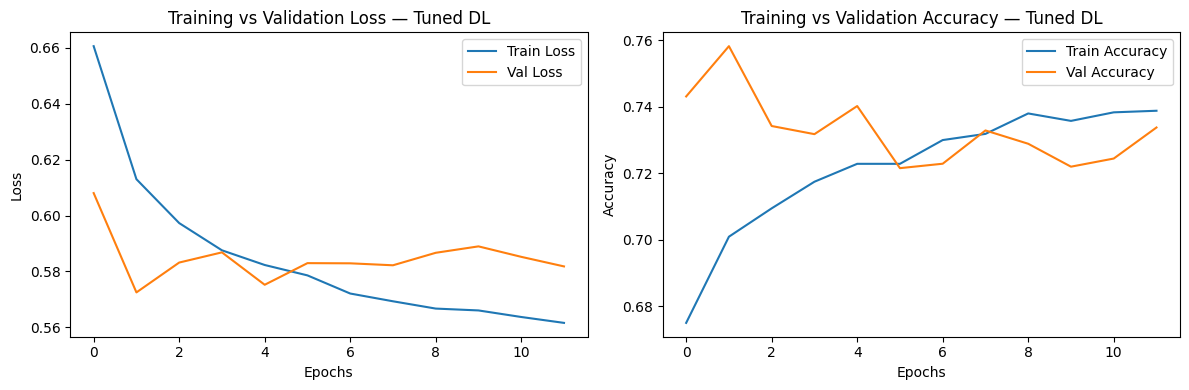

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss — Tuned DL')
plt.legend()


# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy — Tuned DL')
plt.legend()

plt.tight_layout()
plt.show()


**Training Curve Analysis - Tuned Deep Learning Model**

**Loss Curves (Training vs Validation)**
- Both training and validation loss decrease smoothly across epochs, indicating stable and effective learning. The validation loss stabilizes after approximately epoch 6, suggesting the model has reached optimal performance on unseen data.
- The small gap between training and validation loss indicates minimal overfitting and good generalization.

**Accuracy Curves (Training vs Validation)**
- Training accuracy steadily increases to about 0.75, while validation accuracy improves early and stabilizes around 0.73-0.74.
-  The close alignment between training and validation accuracy curves shows that the model maintains consistent performance on both training and unseen data.

**Overall Interpretation**
- Compared to earlier models, these curves demonstrate improved generalization and training stability. The addition of Batch Normalization and Dropout effectively regularizes the deeper network, preventing overfitting while allowing the model to learn meaningful patterns.
- This confirms that architectural tuning has enhanced the model’s reliability and suitability for real-world credit default prediction.

## **Optimal Classification Threshold Analysis**

To determine the best decision boundary for classifying credit card defaults, model performance was evaluated across classification thresholds ranging from 0.10 to 0.90. For each threshold, precision, recall, and F1-score were computed using predicted probabilities from the tuned deep learning model.

**Precision-Recall Trade-off Across Thresholds**
- The evaluation shows the expected trade-off between precision and recall:
- Precision increases as threshold increases
- A higher threshold requires stronger model confidence before predicting default.
- This reduces false positives but may miss some real defaulters.
- Recall decreases as threshold increases
A higher threshold makes it harder to classify customers as defaulters.
- This increases false negatives (missed defaulters).
- Low thresholds (0.10–0.30)
   - High recall but low precision.
   - Many customers are flagged as defaulters, including many non-defaulters.
- High thresholds (0.70–0.90)
   - High precision but low recall.
   - Only very risky customers are flagged, but many defaulters are missed.

In [54]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

# Define a range of classification thresholds to evaluate
thresholds = np.arange(0.1, 0.95, 0.05)

precision_scores = []
recall_scores = []
f1_scores = []

# Calculate metrics for each threshold
for t in thresholds:
    y_pred_threshold = (y_test_proba > t).astype(int)

    # Ensure y_pred_threshold is a 1D array
    y_pred_threshold = y_pred_threshold.flatten()

    # Calculate precision, recall, and F1-score for the positive class (1 = default)
    prec = precision_score(y_test, y_pred_threshold, pos_label=1, average='binary')
    rec = recall_score(y_test, y_pred_threshold, pos_label=1, average='binary')
    f1 = f1_score(y_test, y_pred_threshold, pos_label=1, average='binary')

    precision_scores.append(prec)
    recall_scores.append(rec)
    f1_scores.append(f1)

print("Precision, Recall, and F1-scores calculated for various thresholds.")

Precision, Recall, and F1-scores calculated for various thresholds.


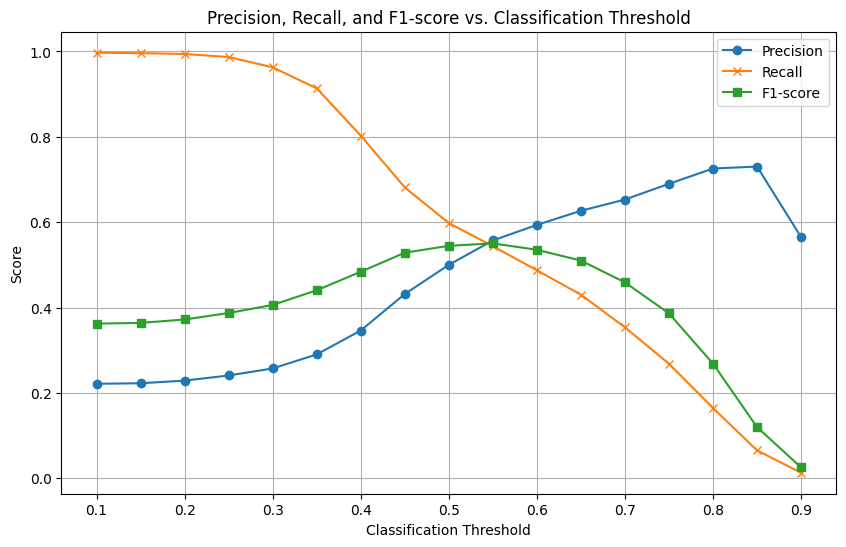

Plot of Precision, Recall, and F1-score against Classification Thresholds displayed successfully.


In [55]:
import matplotlib.pyplot as plt

# Plot the metrics against thresholds
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision_scores, label='Precision', marker='o')
plt.plot(thresholds, recall_scores, label='Recall', marker='x')
plt.plot(thresholds, f1_scores, label='F1-score', marker='s')

# Add labels, title, and legend
plt.xlabel('Classification Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1-score vs. Classification Threshold')
plt.legend()
plt.grid(True)
plt.show()

print("Plot of Precision, Recall, and F1-score against Classification Thresholds displayed successfully.")

In [56]:
max_f1_index = np.argmax(f1_scores)
optimal_threshold = thresholds[max_f1_index]
max_f1_score = f1_scores[max_f1_index]

print(f"Optimal Threshold: {optimal_threshold:.2f}")
print(f"Maximum F1-score: {max_f1_score:.2f}")

Optimal Threshold: 0.55
Maximum F1-score: 0.55


141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Tuned DL (Class Weights, threshold=0.55)
Precision: 0.557157569515963
Recall: 0.5437185929648242
F1: 0.5503560528992879
TN: 3075
FP: 430
FN: 454
TP: 541

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.88      0.87      3505
           1       0.56      0.54      0.55       995

    accuracy                           0.80      4500
   macro avg       0.71      0.71      0.71      4500
weighted avg       0.80      0.80      0.80      4500



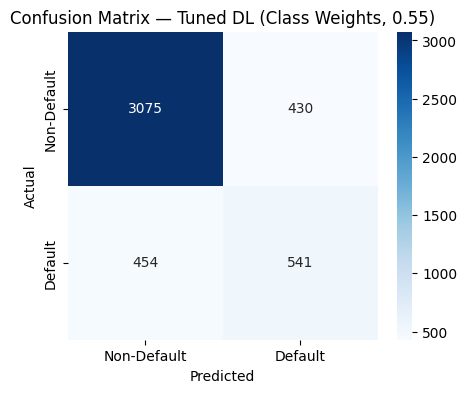

In [57]:
# 4. Evaluation (Threshold = 0.55)
y_test_proba = model.predict(X_test_scaled)
y_pred = (y_test_proba > 0.55).astype(int)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print("\nTuned DL (Class Weights, threshold=0.55)")
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 5. Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-Default","Default"],
            yticklabels=["Non-Default","Default"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Tuned DL (Class Weights, 0.55)")
plt.show()


**Observations:**
- Overall Accuracy: 0.80, improvement over 0.50 threshold.
- Class 0: Recall = 0.88, False Positives reduced to 430, fewer unnecessary alerts.
- Class 1: Recall = 0.54, Precision = 0.56, F1 = 0.55, maintains best balance between precision and recall.

**Conclusion:**
- Optimizing the threshold improves precision for defaulters while reducing false alarms for non-defaulters.
- Provides the most balanced and reliable predictions.
- Slightly increases False Negatives, but reduces False Positives - favorable if cost of false alarms is high.

## **Permutation Importance for Tuned Deep Learning Model**
- Permutation importance was applied to identify which features most influence the tuned deep learning model's ability to predict credit card default. This method evaluates feature importance by measuring the decrease in model performance when a feature's values are randomly shuffled.
- Because the primary objective is accurate detection of defaulters (minority class), importance was assessed using the F1-score of class 1 rather than overall accuracy. A custom wrapper was created to adapt the trained Keras model to the scikit-learn interface, along with a custom scoring function based on the classification threshold of 0.50.
- Permutation importance was then computed on the scaled test dataset to obtain stable feature importance estimates.

**What is Permutation Importance?**

Permutation importance tells you which features your model thinks are most important.

**How it works:**
- Take one feature (like pay_trend) and shuffle its values randomly.
- See if the model’s accuracy (or F1-score) goes down.
- If the performance drops a lot → the feature is important.
- If nothing changes → the feature is not very important.

**Why it's useful:**
- Shows which features really matter for predictions.
- Helps you remove unimportant features or focus on the key ones.
- Works with any model, not just one type.

In [58]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import f1_score

# 2. Create a wrapper function for the Keras model that implements fit and predict_proba
class KerasClassifierWrapper:
    def __init__(self, model, threshold=0.55):
        self.model = model
        self.threshold = threshold

    # Dummy fit method to satisfy sklearn's estimator interface
    def fit(self, X, y):
        pass

    def predict_proba(self, X):
        # Return raw probabilities from the Keras model
        return self.model.predict(X, verbose=0)

    def predict(self, X):
        # Return binary predictions based on the threshold
        probabilities = self.predict_proba(X)
        return (probabilities > self.threshold).astype(int)

# 3. Define custom scoring function for minority class F1-score, compatible with permutation_importance
def f1_score_minority_scorer(estimator, X, y_true):
    # Get predicted probabilities from the wrapped Keras model
    y_pred_proba = estimator.predict_proba(X)
    # Convert probabilities to binary predictions using the estimator's threshold
    y_pred = (y_pred_proba > estimator.threshold).astype(int)
    # Calculate F1-score for the positive class (label 1)
    return f1_score(y_true, y_pred, pos_label=1, average='binary')

# Instantiate the wrapper with the tuned model
model_wrapper = KerasClassifierWrapper(model, threshold=0.55) # Using the tuned 'model'

# 4. Calculate permutation importance
result = permutation_importance(
    model_wrapper,
    X_test_scaled,
    y_test,
    scoring=f1_score_minority_scorer, # Use the new scoring function
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

print("Permutation importance calculated successfully.")

Permutation importance calculated successfully.


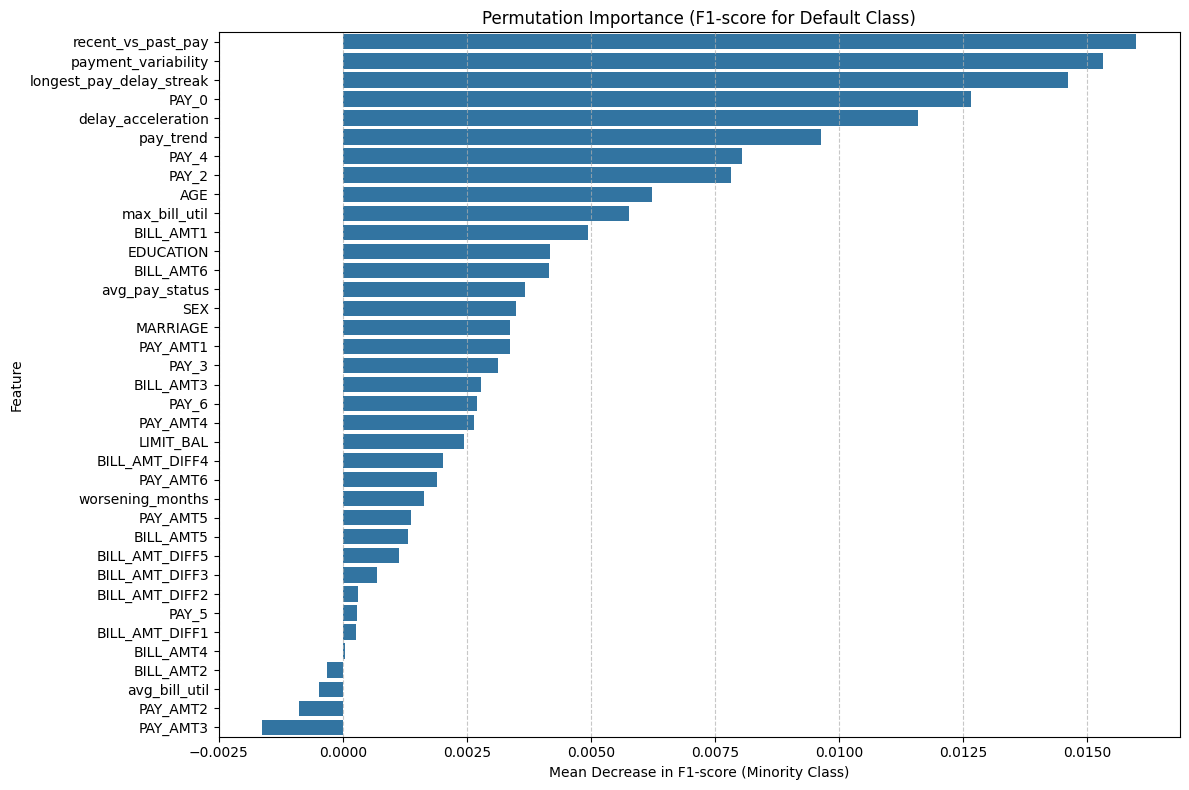

Feature importances visualized successfully.


In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get feature names from the processed training data
feature_names = X_train_processed.columns

# Create a DataFrame to store feature importances
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
})

# Sort by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='importance_mean', ascending=False)

# Plotting the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='importance_mean', y='feature', data=feature_importance_df)
plt.xlabel('Mean Decrease in F1-score (Minority Class)')
plt.ylabel('Feature')
plt.title('Permutation Importance (F1-score for Default Class)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Feature importances visualized successfully.")

In [60]:
display(feature_importance_df)

,feature,importance_mean,importance_std
30,recent_vs_past_pay,0.015984,0.002714
31,payment_variability,0.015319,0.004810
28,longest_pay_delay_streak,0.014610,0.005819
2,PAY_0,0.012649,0.003102
32,delay_acceleration,0.011595,0.001451
29,pay_trend,0.009633,0.002312
5,PAY_4,0.008037,0.003956
3,PAY_2,0.007823,0.002729
1,AGE,0.006229,0.002416
22,max_bill_util,0.005763,0.002969


**Observation**

Permutation importance identified several repayment-behavior features as the strongest predictors of credit card default. These features capture how a customer's payment behavior changes over time, which is directly related to financial stress and default risk.

**recent_vs_past_pay**
  - What it measures: Difference between the most recent repayment status and the average of previous months.
  - Why it’s important: A sudden worsening in the latest payment (e.g., recently missed payment after being regular) is a strong early signal of financial trouble. Credit default often begins with a recent deterioration rather than long-term bad history.

**payment_variability**
  - What it measures: Variation (instability) in repayment status across months.
  - Why it’s important: Customers with unstable payment patterns (sometimes on time, sometimes late) are less financially consistent and more likely to default than customers with stable repayment behavior.

**longest_pay_delay_streak**
  - What it measures: Longest consecutive sequence of delayed payments.
  - Why it's important: Repeated consecutive delays show persistent repayment difficulty rather than occasional mistakes. Longer delay streaks strongly correlate with serious delinquency and eventual default.

**PAY_0 (Most Recent Repayment Status)**
  - What it measures: Current month repayment status.
  - Why it’s important: The latest payment behavior is one of the strongest predictors of near-term default. If a borrower is currently late, the probability of default in the next period increases substantially.

**delay_acceleration**
  - What it measures: Change in delay between recent months (PAY_0 - PAY_2).
  - Why it's important: If delays are increasing rapidly, the borrower's financial condition is worsening. Accelerating delinquency is more dangerous than stable delinquency.

**Model insight:** detects worsening speed of risk.

**pay_trend**
  - What it measures: Overall slope of repayment status over time.
  - Why it's important: Captures long-term direction:
     - Positive trend - getting worse
     - Negative trend - improving
  - A worsening trend indicates gradual financial deterioration leading toward default.

**Model insight:** detects long-term deterioration.

**Overall Interpretation:**
- The most important features are about repayment behavior over time, not customer personal details.
- This means the model focuses on how customers pay their bills, not who they are.
- Customers who show recent missed or delayed payments are more likely to default.
- Unstable payment patterns (sometimes paying, sometimes not) increase risk.
- Repeated late payments strongly indicate financial difficulty.
- So, the model learned a realistic rule:
   - Past repayment behavior predicts future default risk.
- This matches real banking practice, where payment history is the strongest risk indicator.

## **Goal of the Code**

The purpose of this code is to:
- find where the tuned model made mistakes
- separate them into:
  - False Positives (FP) - predicted default but actually no default
  - False Negatives (FN) - predicted no default but actually default
Then extract their features for analysis.

In [61]:
import numpy as np
import pandas as pd

# Flatten y_pred to ensure it's a 1D array for element-wise comparisons
y_pred = y_pred.flatten()

# Identify indices of False Positives (FP) and False Negatives (FN)
# FP: Actual is 0, Predicted is 1
fp_indices = np.where((y_test == 0) & (y_pred == 1))[0]

# FN: Actual is 1, Predicted is 0
fn_indices = np.where((y_test == 1) & (y_pred == 0))[0]

print(f"Number of False Positives (FP): {len(fp_indices)}")
print(f"Number of False Negatives (FN): {len(fn_indices)}")

# Extract feature data for FP and FN instances
# X_test_processed's index might not be contiguous after train_test_split
# Using .iloc with the numerical indices directly from y_test will work.

X_fp = X_test_processed.iloc[fp_indices]
X_fn = X_test_processed.iloc[fn_indices]

print("\nHead of X_fp (False Positives):")
display(X_fp.head())

print("\nHead of X_fn (False Negatives):")
display(X_fn.head())

Number of False Positives (FP): 430
Number of False Negatives (FN): 454

Head of X_fp (False Positives):


,LIMIT_BAL,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,avg_pay_status,avg_bill_util,max_bill_util,BILL_AMT_DIFF1,BILL_AMT_DIFF2,BILL_AMT_DIFF3,BILL_AMT_DIFF4,BILL_AMT_DIFF5,longest_pay_delay_streak,pay_trend,recent_vs_past_pay,payment_variability,delay_acceleration,worsening_months,SEX,EDUCATION,MARRIAGE
22310,100000,30,2,2,2,2,2,2,29668,32463,33350,34003,34647,35348,3600,1700,1500,1500,1400,0,2.0,0.332465,0.35348,-2795,-887,-653,-644,-701,6,1.590241e-17,0.0,0.000000,0,0,2,1,2
9419,130000,29,2,2,0,0,0,-1,172094,156589,145398,136115,138893,127502,0,3300,2500,2778,130000,3689,0.5,1.123835,1.32380,15505,11191,9283,-2778,11391,2,6.000000e-01,1.8,1.224745,0,2,2,2,2
21319,100000,47,1,2,0,0,0,0,99823,96932,96924,96122,97432,95062,0,3579,3472,3287,3590,10179,0.5,0.970492,0.99823,2891,8,802,-1310,2370,2,3.142857e-01,0.6,0.836660,-1,1,1,2,1
18072,10000,29,1,2,2,2,2,0,8393,9069,8019,5819,5626,5621,1000,2000,1000,0,2000,1000,1.5,0.709117,0.90690,-676,1050,2200,193,5,5,1.428571e-01,-0.6,0.836660,-1,1,1,2,2
4556,150000,33,1,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,-1.5,0.000000,0.00000,0,0,0,0,0,1,4.285714e-01,3.0,1.224745,3,1,1,1,1



Head of X_fn (False Negatives):


,LIMIT_BAL,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,avg_pay_status,avg_bill_util,max_bill_util,BILL_AMT_DIFF1,BILL_AMT_DIFF2,BILL_AMT_DIFF3,BILL_AMT_DIFF4,BILL_AMT_DIFF5,longest_pay_delay_streak,pay_trend,recent_vs_past_pay,payment_variability,delay_acceleration,worsening_months,SEX,EDUCATION,MARRIAGE
12900,150000,46,1,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,-1.500000,0.000000,0.000000,0,0,0,0,0,1,4.285714e-01,3.0,1.224745,3,1,2,3,1
12829,340000,44,0,0,0,0,0,0,327058,335584,330510,272220,269629,266723,16004,312723,9748,9800,9569,12500,0.000000,0.883198,0.987012,-8526,5074,58290,2591,2906,0,0.000000e+00,0.0,0.000000,0,0,1,2,2
14363,20000,46,0,0,0,-2,-2,-2,19401,20650,0,0,0,0,1650,0,0,0,0,0,-1.000000,0.333758,1.032500,-1249,20650,0,0,0,0,5.142857e-01,1.2,1.095445,0,1,1,2,2
17060,20000,22,0,0,0,-1,-1,0,19667,19974,5491,831,20088,19733,1500,1000,831,20500,1000,1100,-0.333333,0.714867,1.004400,-307,14483,4660,-19257,355,0,1.142857e-01,0.4,0.516398,0,1,2,2,1
23357,30000,34,0,0,-1,2,-1,0,8090,0,3398,2855,2115,521,0,6253,0,2115,0,2000,0.000000,0.094328,0.269667,8090,-3398,543,740,1594,1,-2.191419e-17,0.0,1.095445,0,2,2,3,1


The predicted labels from the tuned deep learning model were compared with the true test labels to identify misclassified instances. False Positives (FP) were defined as cases where the model predicted default but the actual outcome was non-default, while False Negatives (FN) were defined as cases where the model predicted non-default but the actual outcome was default. The indices of these misclassified instances were obtained using logical conditions and NumPy indexing. The corresponding feature values were then extracted from the processed test dataset (X_test_processed) using positional indexing (.iloc). This enabled detailed statistical and visual analysis of the characteristics of misclassified customers to understand model error patterns.

This code compares model predictions with actual labels to identify false positives and false negatives. It then extracts their feature values from the test dataset so we can analyze the characteristics of misclassified customers and understand where the model is making errors.

In [62]:
key_features = [
    'LIMIT_BAL','AGE',
    'avg_pay_status','longest_pay_delay_streak',
    'payment_variability','delay_acceleration','worsening_months',
    'avg_bill_util','max_bill_util'
]

print("\nDescriptive statistics for False Positives (FP):")
display(X_fp[key_features].describe())

print("\nDescriptive statistics for False Negatives (FN):")
display(X_fn[key_features].describe())



Descriptive statistics for False Positives (FP):


,LIMIT_BAL,AGE,avg_pay_status,longest_pay_delay_streak,payment_variability,delay_acceleration,worsening_months,avg_bill_util,max_bill_util
count,430.000000,430.000000,430.000000,430.000000,430.000000,430.000000,430.000000,430.000000,430.000000
mean,96465.116279,35.700000,0.859690,2.804651,1.041517,-0.141860,1.132558,0.576594,0.700996
std,90402.196076,9.860365,0.932633,1.638402,0.418737,1.369282,0.827054,0.363951,0.430259
min,10000.000000,22.000000,-1.500000,0.000000,0.000000,-4.000000,0.000000,-0.003840,-0.003840
25%,30000.000000,27.000000,0.333333,2.000000,0.836660,-1.000000,1.000000,0.270317,0.405295
50%,60000.000000,34.000000,0.666667,2.000000,1.032796,0.000000,1.000000,0.667998,0.822450
75%,140000.000000,42.000000,1.333333,4.000000,1.224745,0.000000,1.000000,0.879729,1.004397
max,500000.000000,67.000000,5.500000,6.000000,2.926887,3.000000,5.000000,1.894450,3.384340



Descriptive statistics for False Negatives (FN):


,LIMIT_BAL,AGE,avg_pay_status,longest_pay_delay_streak,payment_variability,delay_acceleration,worsening_months,avg_bill_util,max_bill_util
count,454.000000,454.000000,454.000000,454.000000,454.000000,454.000000,454.000000,454.000000,454.000000
mean,161585.903084,35.645374,-0.523862,0.319383,0.433356,0.310573,0.511013,0.324799,0.449331
std,129753.188613,9.082636,0.716313,0.528836,0.503644,0.964273,0.653476,0.364463,0.461047
min,10000.000000,21.000000,-2.000000,0.000000,0.000000,-4.000000,0.000000,-0.200154,-0.031740
25%,50000.000000,28.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.008411,0.022910
50%,130000.000000,34.000000,-0.166667,0.000000,0.000000,0.000000,0.000000,0.109266,0.223107
75%,240000.000000,42.000000,0.000000,1.000000,0.816497,0.000000,1.000000,0.649298,0.938953
max,710000.000000,63.000000,0.833333,3.000000,1.974842,3.000000,2.000000,1.892923,2.027840


### **Error Analysis Observations (FP vs FN)**

- **Credit Limit Difference:** False Positives generally have much lower credit limits (96K) compared to False Negatives (162K). This suggests the model tends to flag low-limit customers as risky even when they do not actually default.
- **Repayment Behavior Contrast:** False Positives show clearly worse repayment behavior (avg_pay_status 0.86) while False Negatives have mostly on-time or early payments (avg_pay_status ≈-0.52). This indicates the model relies heavily on past payment delays.
- **Delay Consistency:** False Positives have longer continuous delay streaks (2.8 months) compared to almost no delay streak in False Negatives (]0.3). This shows persistent delays strongly influence the model’s risk prediction.
- **Payment Stability:** Payment volatility is much higher in False Positives (1.04) than False Negatives (0.43), meaning unstable repayment patterns often trigger false alarms.
- **Recent Deterioration Signals:** False Positives have more worsening months (1.13 vs 0.51), suggesting the model reacts strongly to recent negative trends even when default does not occur.
- **Credit Utilization:** False Positives use a larger share of their credit (avg utilization ≈0.58) than False Negatives (0.32). Higher usage is interpreted by the model as higher risk.
- **Overall Pattern:** False Positives look financially stressed but ultimately do not default, while False Negatives appear financially healthy yet eventually default. This confirms the model prioritizes visible repayment stress over hidden risk factors.

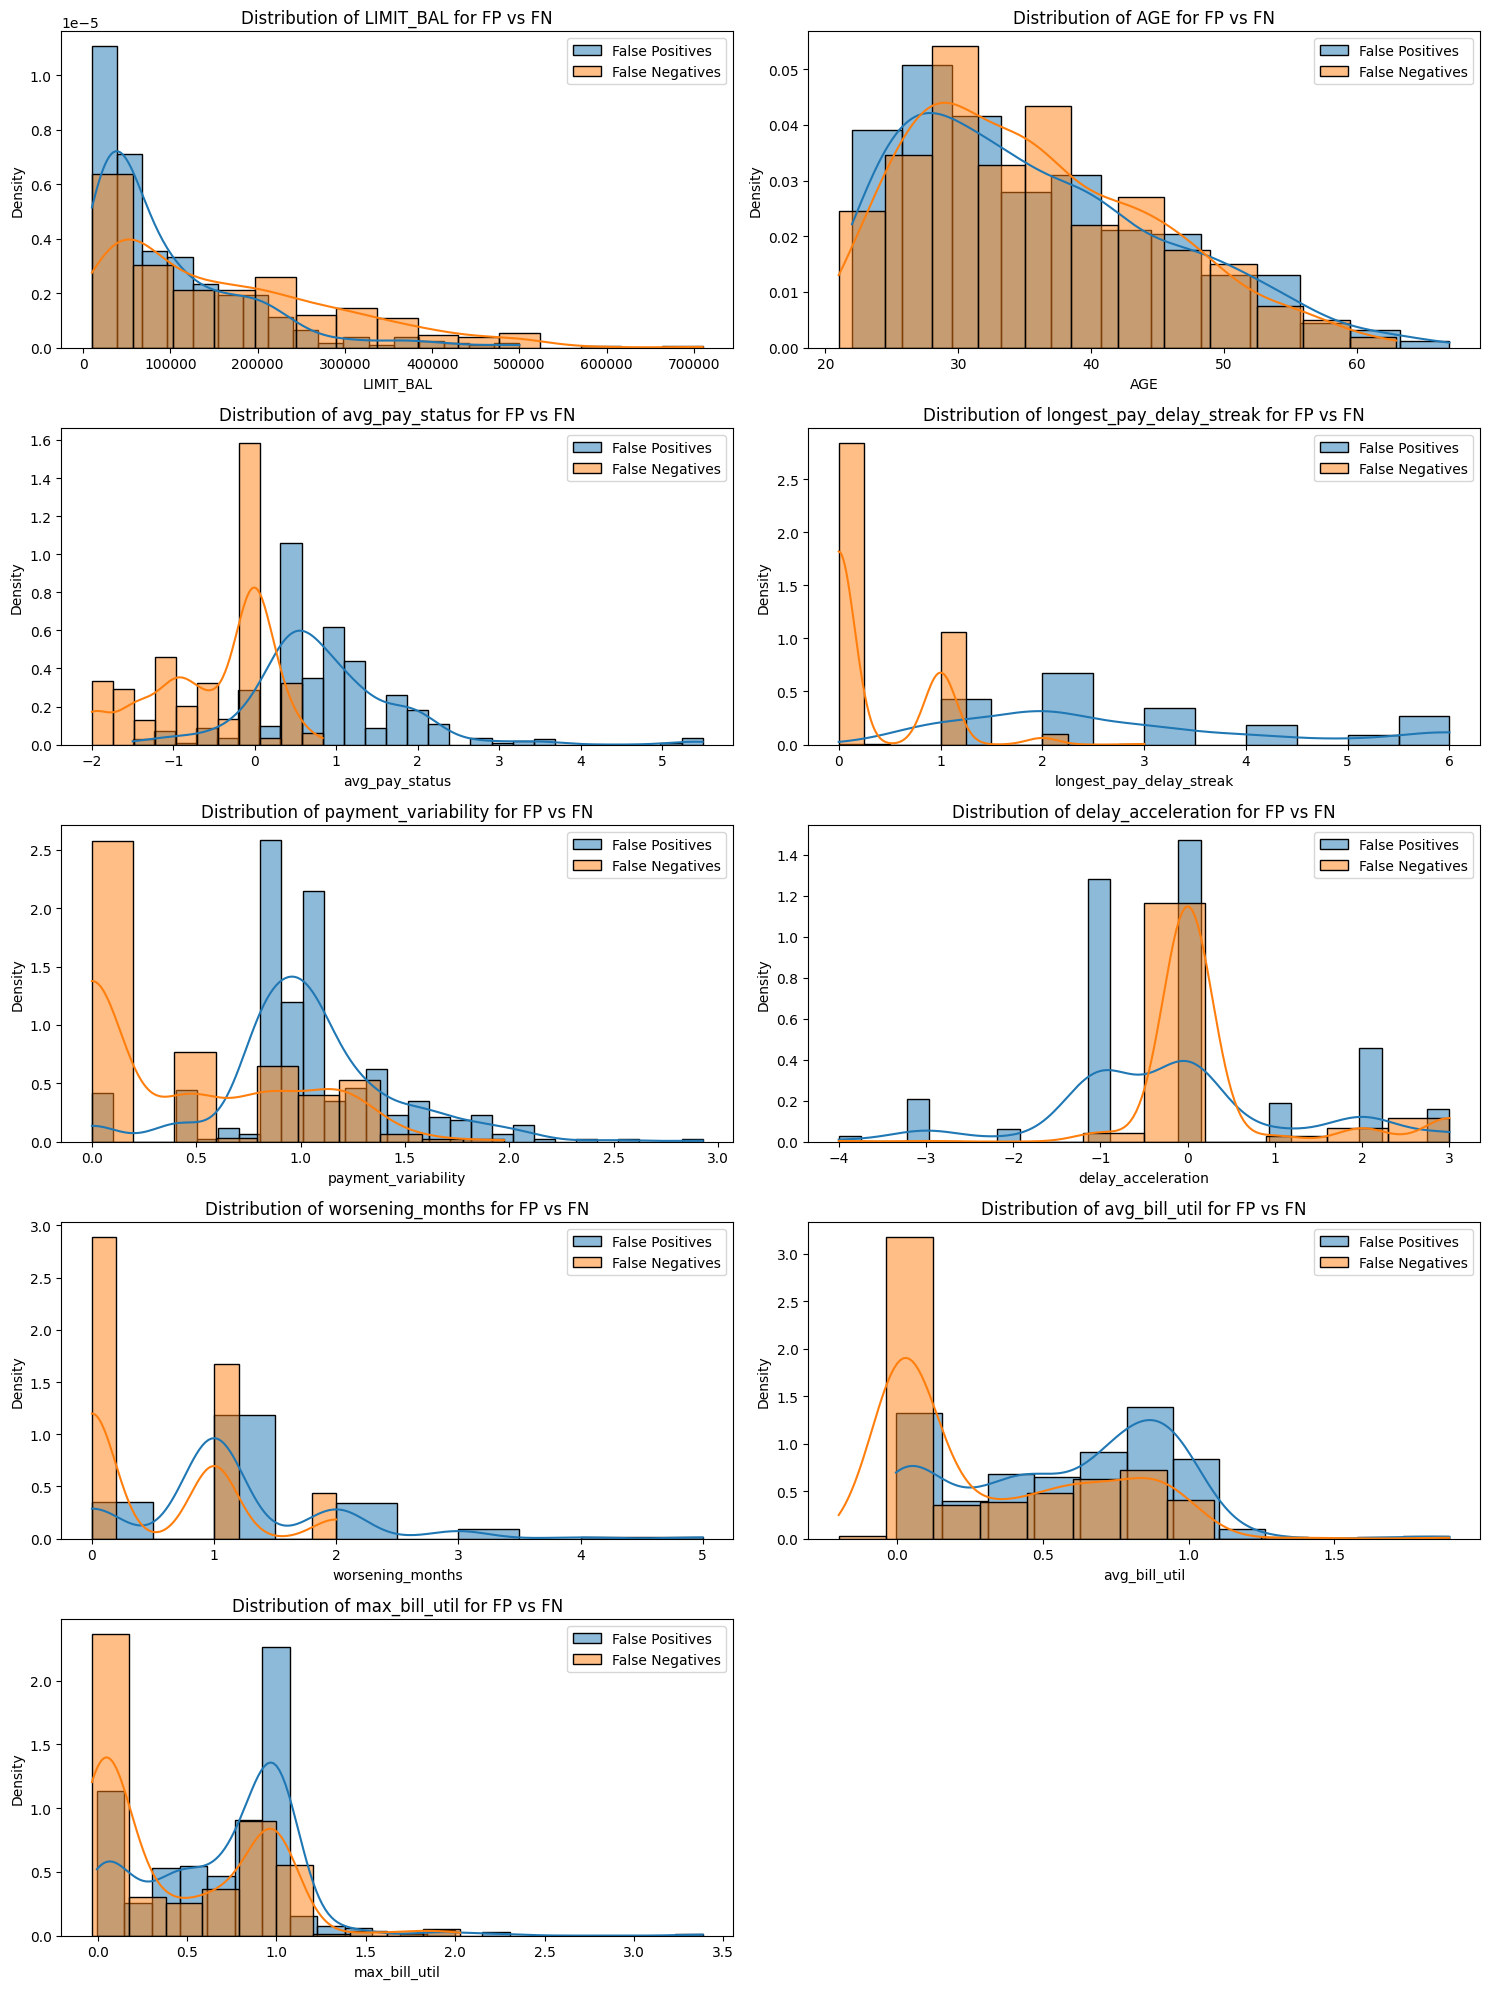

Comparative distribution plots for key numerical features created successfully.


In [63]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

n_features = len(key_features)
cols = 2
rows = math.ceil(n_features / cols)

plt.figure(figsize=(15, rows * 4))

for i, feature in enumerate(key_features):
    plt.subplot(rows, cols, i + 1)
    sns.histplot(X_fp[feature], label='False Positives', kde=True, stat='density', alpha=0.5)
    sns.histplot(X_fn[feature], label='False Negatives', kde=True, stat='density', alpha=0.5)
    plt.title(f'Distribution of {feature} for FP vs FN')
    plt.xlabel(feature)
    plt.ylabel('Density')
    plt.legend()

plt.tight_layout()
plt.show()

print("Comparative distribution plots for key numerical features created successfully.")


**Interpretation of Numerical Feature Distribution (FP vs FN)**
1. **False Positives (FP)**
  - (Predicted Default, but actually Non-Default)

- Key pattern: These customers show noticeable repayment difficulties, but they ultimately do not default.

**Observations:**
- **Higher payment delay indicators
(PAY_0, avg_pay_status, longest_pay_delay_streak, payment_variability, delay_acceleration, worsening_months)**
   -  FP customers have more delays and unstable repayment patterns.
   -  The model interprets temporary or moderate repayment issues as default risk.
- **Lower credit limits (LIMIT_BAL)**
   - FP customers often have smaller credit limits.
   - The model assumes lower limits = financially weaker customers.
- **Moderate to high utilization**
   - Using a large portion of a small credit limit appears risky to the model.
- **Age not important**
   - Age distributions overlap with FN.

**FP error meaning:**
  - The model is too cautious.
  - It flags customers with short-term or mild repayment problems as defaulters.

2. **False Negatives (Predicted Non-Default, Actually Default)**
- Key pattern: These customers look financially healthy in history, but still default.

**Observations:**
- **Clean or stable payment history**
   - Low delays and stable repayment features.
   - The model assumes they are safe borrowers.

- **Higher credit limits**
   - FN customers often have large credit limits.
   - The model associates high limit with low risk.

- **Moderate utilization**
   - Appears financially controlled to the model.

- **Age not important**
   - Similar to FP group.

**FN error meaning:**
- The model misses hidden risk.
- It trusts good payment history and high credit limits too much.



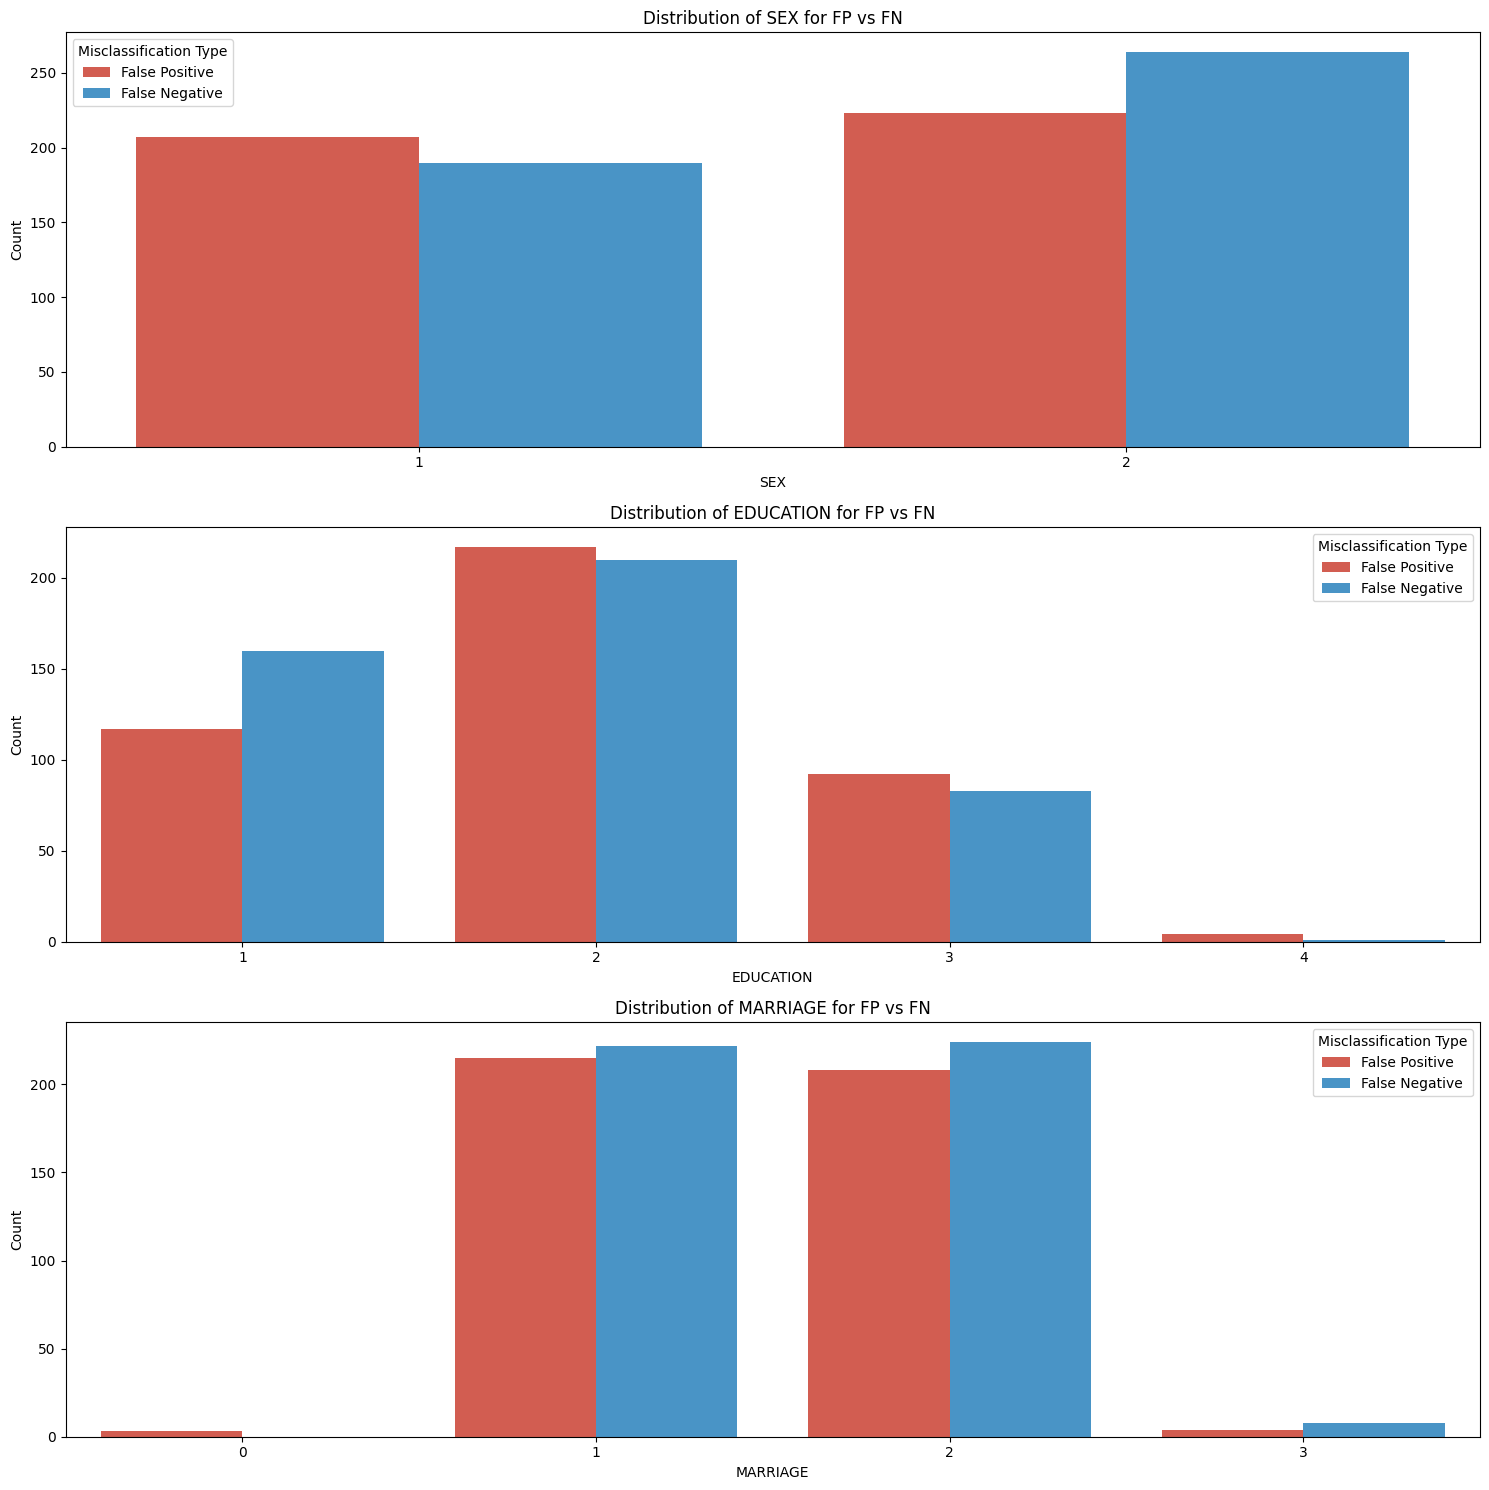

Comparative count plots for key categorical features created successfully.


In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# categorical_features = ['SEX', 'EDUCATION', 'MARRIAGE']

plt.figure(figsize=(15, 5 * len(categorical_features)))

for i, feature in enumerate(categorical_features):
    plt.subplot(len(categorical_features), 1, i + 1)

    # Combine FP and FN data for the current feature with a label for misclassification type
    fp_data = X_fp[[feature]].copy()
    fp_data['Misclassification_Type'] = 'False Positive'
    fn_data = X_fn[[feature]].copy()
    fn_data['Misclassification_Type'] = 'False Negative'
    combined_data = pd.concat([fp_data, fn_data])

    sns.countplot(x=feature, hue='Misclassification_Type', data=combined_data, palette={'False Positive': '#E74C3C', 'False Negative': '#3498DB'})
    plt.title(f'Distribution of {feature} for FP vs FN')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.legend(title='Misclassification Type')

plt.tight_layout()
plt.show()

print("Comparative count plots for key categorical features created successfully.")

**Categorical Feature Error Analysis (FP vs FN)**

- **SEX**
  - Observation: More errors (both false positives and false negatives) occur for females (SEX = 2) than males (SEX = 1).
  - Why: Females are the majority in the dataset. When one group has more samples, the model naturally makes more errors in that group.
  - **Insight:** Gender itself is not causing misclassification. Errors simply follow the data distribution, so SEX is not a strong factor in model mistakes.

- **EDUCATION**
  - Observation:
     - False Positives: Mostly University (2) and High School (3)
     - False Negatives: Mostly University (2) and Graduate School (1)
  - Why: The model may assume higher education means lower financial risk.
So:
  - Some educated customers with small delays are wrongly flagged (FP)
  - Some educated customers who actually default are missed (FN)
  - **Insight:**
Education influences model decisions more than other categorical features.
The model’s assumption about education and risk is not always correct, causing both types of errors.

- **MARRIAGE**
  - Observation: Errors appear in both Married (1) and Single (2), slightly more for married customers.
  - Why: Married customers are more common in the dataset. More samples → more errors.
  - **Insight:** Marital status alone does not strongly affect model mistakes. Errors mainly reflect data proportion, not true risk difference.

**Overall Insight (Categorical Features)**
- Error patterns mostly follow dataset distribution
- Education shows some influence on errors
- SEX and MARRIAGE have weak impact
- Repayment behavior and credit features remain the main drivers of misclassification

**Final Conclusion:**
Demographic features provide background information, but the model’s errors are mainly driven by repayment history and credit behavior, not categorical demographics.

# **Final Model Comparison**
| Model                                   | Threshold | Precision | Recall | F1-score | TN   | FP  | FN  | TP  | Notes                                                                                         |
| --------------------------------------- | --------- | --------- | ------ | -------- | ---- | --- | --- | --- | --------------------------------------------------------------------------------------------- |
| **Baseline Model**                      | 0.50      | 0.71      | 0.32   | 0.44     | 3373 | 132 | 677 | 318 | Fully connected NN, no class weights; poor recall for defaulters                              |
| **DL + Class Weights + Early Stopping** | 0.50      | 0.46      | 0.62   | 0.53     | 2784 | 721 | 376 | 619 | Class weighting improved defaulter detection; model penalizes mistakes on risky customers     |
| **Tuned DL (3 layers, Class Weights)**  | 0.50      | 0.50      | 0.60   | 0.55     | 2912 | 593 | 396 | 599 | Added third hidden layer, batch norm, dropout; better stability and balanced performance      |
| **Tuned DL (3 layers, Class Weights)**  | 0.55      | 0.56      | 0.54   | 0.55     | 3075 | 430 | 454 | 541 | Optimized threshold for best balance between detecting defaulters and minimizing false alarms |

**Key Takeaways:**
- Adding class weights improved recall, catching more defaulters.
- Architectural tuning (extra layers, batch norm, dropout) increased model stability and F1-score.
- Adjusting the threshold to 0.55 optimized the balance between precision and recall, reducing false positives while maintaining defaulter detection.
- Overall, the final tuned model at threshold 0.55 provides the best trade-off for reliable credit default prediction.

### **After identifying model performance characteristics and analyzing misclassification patterns (FP/FN), the tuned deep learning model with optimized threshold was selected for deployment as the final credit-default prediction system.**

In [65]:
def create_engineered_features(df):

    pay_cols_full = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
    pay_cols_ordered_oldest_recent = ['PAY_6', 'PAY_5', 'PAY_4', 'PAY_3', 'PAY_2', 'PAY_0']
    bill_amt_cols = ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']

    # Average repayment status
    df['avg_pay_status'] = df[pay_cols_full].mean(axis=1)

    # Longest consecutive payment delay streak
    def calculate_longest_delay_streak(row):
        current_streak = 0
        max_streak = 0
        for col in pay_cols_full:
            # A payment delay is indicated by PAY_N > 0
            if row[col] > 0:
                current_streak += 1
            else:
                max_streak = max(max_streak, current_streak)
                current_streak = 0
        max_streak = max(max_streak, current_streak) # Check for streak ending at the last month
        return max_streak

    df['longest_pay_delay_streak'] = df.apply(calculate_longest_delay_streak, axis=1)

    # Repayment Trend (overall worsening or improving) using np.polyfit
    def repayment_trend(row):
        y = row.values
        x = np.arange(len(y))
        slope = np.polyfit(x, y, 1)[0]
        return slope
    df['pay_trend'] = df[pay_cols_ordered_oldest_recent].apply(repayment_trend, axis=1)

    # Recent vs Past Repayment (sudden deterioration)
    df['recent_vs_past_pay'] = df['PAY_0'] - df[['PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']].mean(axis=1)

    # Repayment Volatility (instability over months)
    df['payment_variability'] = df[pay_cols_full].std(axis=1)

    # Delay Acceleration (recent worsening speed)
    df['delay_acceleration'] = df['PAY_0'] - df['PAY_2']

    # Worsening Months Count (consecutive deterioration)
    def worsening_months(row):
        vals = row.values
        count = 0
        for i in range(1, len(vals)):
            if vals[i] > vals[i-1]:
                count += 1
        return count
    df['worsening_months'] = df[pay_cols_ordered_oldest_recent].apply(worsening_months, axis=1)

    # Credit utilization
    bill_util_cols = []
    df['LIMIT_BAL_SAFE'] = df['LIMIT_BAL'].replace(0, pd.NA)

    for i, col in enumerate(bill_amt_cols):
        util_col = f'BILL_UTIL{i+1}'
        df[util_col] = df[col] / df['LIMIT_BAL_SAFE']
        bill_util_cols.append(util_col)

    # Aggregate utilization features
    df['avg_bill_util'] = df[bill_util_cols].mean(axis=1)
    df['max_bill_util'] = df[bill_util_cols].max(axis=1)

    # Drop intermediate BILL_UTIL columns and LIMIT_BAL_SAFE
    df.drop(columns=bill_util_cols + ['LIMIT_BAL_SAFE'], inplace=True, errors='ignore')

    # BILL DIFFERENCES
    for i in range(1, 6):
        df[f'BILL_AMT_DIFF{i}'] = df[f'BILL_AMT{i}'] - df[f'BILL_AMT{i+1}']

    return df

In [66]:
import joblib

joblib.dump(X_train_processed.columns.tolist(), "feature_names.pkl")

print("feature_names.pkl saved")

feature_names.pkl saved


In [67]:
from tensorflow.keras.models import load_model
import joblib
import pandas as pd

loaded_model = load_model("credit_model.h5")
loaded_scaler = joblib.load("scaler.pkl")
feature_names = joblib.load("feature_names.pkl")

print("Loaded successfully")

Loaded successfully


In [69]:
import pandas as pd

# Example: multiple new clients
new_data_raw = pd.DataFrame({
    'LIMIT_BAL': [100000, 50000, 200000],
    'SEX': [2, 1, 2],          # 1 = Male, 2 = Female
    'EDUCATION': [2, 1, 3],    # 1 = High School, 2 = University, 3 = Graduate
    'MARRIAGE': [1, 2, 1],     # 1 = Married, 2 = Single
    'AGE': [35, 40, 28],
    'PAY_0': [0, 2, -1],
    'PAY_2': [0, 1, 0],
    'PAY_3': [0, 0, 0],
    'PAY_4': [0, 0, 0],
    'PAY_5': [0, 0, 0],
    'PAY_6': [0, 0, 0],
    'BILL_AMT1': [30000, 5000, 20000],
    'BILL_AMT2': [25000, 4000, 15000],
    'BILL_AMT3': [20000, 3000, 10000],
    'BILL_AMT4': [15000, 2000, 8000],
    'BILL_AMT5': [10000, 1000, 5000],
    'BILL_AMT6': [5000, 500, 2000],
    'PAY_AMT1': [1000, 500, 1500],
    'PAY_AMT2': [1000, 500, 1000],
    'PAY_AMT3': [1000, 500, 1000],
    'PAY_AMT4': [1000, 500, 1000],
    'PAY_AMT5': [1000, 500, 1000],
    'PAY_AMT6': [1000, 500, 1000]
})

print("Raw new data points created:")
display(new_data_raw)

Raw new data points created:


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,100000,2,2,1,35,0,0,0,0,0,0,30000,25000,20000,15000,10000,5000,1000,1000,1000,1000,1000,1000
1,50000,1,1,2,40,2,1,0,0,0,0,5000,4000,3000,2000,1000,500,500,500,500,500,500,500
2,200000,2,3,1,28,-1,0,0,0,0,0,20000,15000,10000,8000,5000,2000,1500,1000,1000,1000,1000,1000


In [70]:
# Apply feature engineering to all rows
new_data_engineered = create_engineered_features(new_data_raw.copy())

print("Engineered new data points:")
display(new_data_engineered)

Engineered new data points:


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,avg_pay_status,longest_pay_delay_streak,pay_trend,recent_vs_past_pay,payment_variability,delay_acceleration,worsening_months,avg_bill_util,max_bill_util,BILL_AMT_DIFF1,BILL_AMT_DIFF2,BILL_AMT_DIFF3,BILL_AMT_DIFF4,BILL_AMT_DIFF5
0,100000,2,2,1,35,0,0,0,0,0,0,30000,25000,20000,15000,10000,5000,1000,1000,1000,1000,1000,1000,0.000000,0,0.000000,0.0,0.000000,0,0,0.175000,0.3,5000,5000,5000,5000,5000
1,50000,1,1,2,40,2,1,0,0,0,0,5000,4000,3000,2000,1000,500,500,500,500,500,500,500,0.500000,2,0.371429,1.8,0.836660,1,2,0.051667,0.1,1000,1000,1000,1000,500
2,200000,2,3,1,28,-1,0,0,0,0,0,20000,15000,10000,8000,5000,2000,1500,1000,1000,1000,1000,1000,-0.166667,0,-0.142857,-1.0,0.408248,-1,0,0.050000,0.1,5000,5000,2000,3000,3000


In [71]:
# Keep only features the model expects
new_data_model = new_data_engineered[feature_names]

# Apply scaler
new_data_scaled = loaded_scaler.transform(new_data_model)

In [72]:
# Predict probabilities
pred_probs = loaded_model.predict(new_data_scaled)
print("Predicted probabilities of default:")
print(pred_probs)

# Predict classes using threshold 0.5
pred_classes = (pred_probs >= 0.5).astype(int)
print("Predicted classes (0 = non-defaulter, 1 = defaulter):")
print(pred_classes)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
Predicted probabilities of default:
[[0.2423239 ]
 [0.7877139 ]
 [0.21113656]]
Predicted classes (0 = non-defaulter, 1 = defaulter):
[[0]
 [1]
 [0]]


**Credit Default Prediction - New Clients**
- **Input Data:**
  - Three sample clients with varying credit limits, education levels, marital status, ages, payment histories, and billing patterns.
- **Predicted Probabilities of Default:**
  - Client 1: 0.24 → Low risk
  - Client 2: 0.79 → High risk
  - Client 3: 0.21 → Low risk
- **Predicted Classes (Threshold = 0.50):**
  - Client 1: Non-defaulter (0)
  - Client 2: Defaulter (1)
  - Client 3: Non-defaulter (0)
- **Observations:**
  - Client 2 has the highest probability of default (0.79) due to:
  - Higher recent delays (PAY_0 = 2)
  - Moderate credit utilization
- **Historical repayment issues compared to others**
  - Clients 1 and 3 show low default probabilities (< 0.25) as their payments are mostly on-time, with stable repayment patterns and manageable credit usage.
  - Engineered features like recent vs. past payment, longest delay streak, and payment variability likely influenced the model to flag Client 2 as high-risk.
  - The model correctly identifies high-risk behavior while avoiding false alarms for financially stable clients.

**Insight:**
  - The model can effectively prioritize clients for intervention based on predicted default risk.
  - Behavioral repayment features dominate the prediction, confirming the importance of temporal payment patterns over static demographics.

## **Final Conclusion**

This project aimed to predict credit card default risk using deep learning, moving step-by-step from raw data exploration to an optimized predictive model. The dataset contained 30,000 customers with no missing values but showed a strong class imbalance, where only 22% of clients defaulted. This imbalance made default prediction challenging and required careful modeling strategies.

Exploratory analysis showed that customer repayment behavior was far more important than demographic characteristics. While factors such as gender, education, and marital status showed only weak relationships with default, repayment history variables clearly separated defaulters from non-defaulters. Customers with repeated payment delays, worsening repayment patterns, and high credit utilization were much more likely to default.

To capture these patterns more effectively, several new behavioral features were engineered, such as average repayment status, longest delay streak, repayment trend, volatility, and bill utilization ratios. These features transformed raw monthly payment data into meaningful indicators of financial stress over time. Correlation analysis confirmed that these engineered repayment features had the strongest relationships with default risk, validating the feature engineering approach.

Model development progressed through multiple stages. The baseline deep learning model achieved good overall accuracy but performed poorly at identifying defaulters due to class imbalance. Introducing class weights significantly improved the model’s ability to detect defaulters, increasing recall and F1-score. Further tuning with regularization and optimized architecture improved stability and generalization, resulting in the best overall model performance.

An important improvement came from adjusting the classification threshold. Instead of the standard 0.50 cutoff, analysis showed that a threshold of 0.55 provided a better balance between detecting defaulters and avoiding false alarms. This adjustment improved precision while maintaining strong recall, producing the most balanced predictions for real-world use.

Feature importance analysis on the tuned model confirmed that repayment behavior features—especially longest delay streak, repayment volatility, and recent repayment deterioration—were the most influential predictors. This highlights that default risk is driven primarily by behavioral repayment patterns rather than static customer characteristics.

Error analysis provided additional insights. False positives often showed moderate delays and lower credit limits, indicating the model was cautiously flagging potentially risky customers. False negatives typically had higher credit limits and relatively clean histories, suggesting that financially stronger profiles can still default unexpectedly. These patterns are consistent with real-world credit risk behavior.

Overall, the final tuned deep learning model, enhanced with engineered behavioral features and an optimized threshold, provides reliable and balanced credit default predictions. The project demonstrates that capturing temporal repayment behavior significantly improves risk detection. Such a model can support financial institutions in identifying high-risk customers early, enabling better credit decisions and proactive risk management.